In [291]:
import pandas as pd
import bs4 as bs
import seaborn as sns
import matplotlib.pyplot as plt
import requests
import sklearn.preprocessing as sk
import numpy as np


In [292]:
def get_real_value(nominal_amt, old_cpi, new_cpi):
    real_value = (nominal_amt * new_cpi) / old_cpi
    return real_value

In [293]:
# url = "https://www.usinflationcalculator.com/inflation/consumer-price-index-and-annual-percent-changes-from-1913-to-2008/"
#
# r = requests.get(url)
# data = r.text
# soup = bs.BeautifulSoup(data, "html.parser")
#
# table = soup.find("table")
#
# rows = table.tbody.find_all("tr")
#
# years = []
# crips = []
#
# for row in rows:
#     year = row.find_all("td")[0].get_text()
#     if year.isdigit() and int(year) < 2017:
#         years.append(int(year))
#         crips.append(row.find_all("td")[13].get_text())
#
# cpi_table = pd.DataFrame({
#     "year": years,
#     "cpi": crips
# })
#
# cpi_table

In [294]:
movies_data = pd.read_csv(
    "data_sets/Dataset1.csv",
    quotechar='"',
    doublequote=True,
    engine='python',
    on_bad_lines='skip',
)


In [295]:
movies_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4974 entries, 0 to 4973
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   color                       4956 non-null   object 
 1   Director_Name               4872 non-null   object 
 2   num_Critic_for_reviews      4927 non-null   float64
 3   duration                    4959 non-null   float64
 4   director_Facebook_likes     4872 non-null   float64
 5   actor_3_Facebook_likes      4953 non-null   float64
 6   actor_2_name                4963 non-null   object 
 7   Actor_1_Facebook_likes      4968 non-null   float64
 8   gross                       4104 non-null   float64
 9   genres                      4974 non-null   object 
 10  actor_1_name                4968 non-null   object 
 11  movie_Title                 4974 non-null   object 
 12  num_voted_users             4974 non-null   int64  
 13   cast_total_facebook_likes  4974 

In [296]:
movies_data.head()

,color,Director_Name,num_Critic_for_reviews,duration,director_Facebook_likes,actor_3_Facebook_likes,actor_2_name,Actor_1_Facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes;
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000;
1,Colour,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0;
2,Colour,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000;
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000;
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0;


In [297]:
movies_data["color"].value_counts()

color
Color               4725
 Black and White     207
Colour                14
color                 10
Name: count, dtype: int64

In [298]:
movies_data["color"] = movies_data["color"].replace({"Colour": "Color", "color": "Color"})
movies_data["color"].value_counts()

color
Color               4749
 Black and White     207
Name: count, dtype: int64

## Содержание датасета:
`color` - цветной или черно-белый фильм

`movie_Title` - название фильма

`genres` - жанры фильма

`duration` - продолжительность фильма в минутах

`language` - язык фильма

`country` - страна производства

`content_rating` - возрастной рейтинг

`title_year` - год выпуска фильма

`movie_imdb_link` - ссылка на страницу фильма на IMDb

`budget` - бюджет фильма

`gross` - кассовые сборы

`Director_Name` - имя режиссера

`actor_1_name`, `actor_2_name`, `actor_3_name` - имена главных актеров

`actor_1_facebook_likes`, `actor_2_facebook_likes`, `actor_3_facebook_likes`, `director_facebook_likes` - количество лайков на Facebook у актеров и режиссера

`cast_total_facebook_likes` - суммарное количество лайков всего актерского состава

`imdb_score` - рейтинг фильма на IMDb

`num_voted_users` - количество пользователей, проголосовавших за фильм

`num_user_for_reviews` - количество пользовательских рецензий

`num_critic_for_reviews` - количество рецензий от критиков

`facenumber_in_poster` - количество лиц на постере фильма

`plot_keywords` - ключевые слова сюжета

`aspect_ratio` - соотношение сторон экрана

`movie_facebook_likes` - количество лайков фильма на Facebook

Избавимся от дубликатов.

In [299]:
movies_data.duplicated().sum()

np.int64(44)

In [300]:
movies_data.drop_duplicates(inplace=True)
movies_data.duplicated().sum()

np.int64(0)

Выясним, есть ли в датасете пропуски.

In [301]:
movies_data.isna().sum()

color                          18
Director_Name                 101
num_Critic_for_reviews         46
duration                       15
director_Facebook_likes       101
actor_3_Facebook_likes         21
actor_2_name                   11
Actor_1_Facebook_likes          6
gross                         860
genres                          0
actor_1_name                    6
movie_Title                     0
num_voted_users                 0
 cast_total_facebook_likes      0
actor_3_name                   21
facenumber_in_poster           13
plot_keywords                 146
movie_imdb_link                 0
num_user_for_reviews           18
language                       13
country                         3
content_rating                295
budget                        476
title_year                    104
actor_2_facebook_likes         11
imdb_score                      0
aspect_ratio                  318
movie_facebook_likes;           0
dtype: int64

Удалим столбцы, содержащие ссылку на страницу фильма, его название и ключевые слова.

In [302]:
movies_data.drop(["movie_imdb_link", "movie_Title", "plot_keywords"], axis=1, inplace=True)

Прежде, чем заполнять пропуски, преобразуем типы данных для столбцов.

In [303]:
str_columns = movies_data.select_dtypes(include='object').columns
str_columns

Index(['color', 'Director_Name', 'actor_2_name', 'genres', 'actor_1_name',
       'actor_3_name', 'language', 'country', 'content_rating',
       'movie_facebook_likes;'],
      dtype='object')

`movie_facebook_likes;` является числовым признаком - приведем его к соответствующему типу и избавимся от символа ";" в имени.

In [304]:
categorial_columns = str_columns.drop("movie_facebook_likes;")

movies_data.rename({"movie_facebook_likes;": "movie_facebook_likes"}, inplace = True, axis=1)
movies_data.rename({" cast_total_facebook_likes": "cast_total_facebook_likes"}, inplace = True, axis=1)
movies_data.rename({"actor_3_Facebook_likes": "actor_3_facebook_likes"}, inplace = True, axis=1)
movies_data.rename({"Actor_1_Facebook_likes": "actor_1_facebook_likes"}, inplace = True, axis=1)

movies_data["movie_facebook_likes"] = movies_data["movie_facebook_likes"].str.replace(";", "")
movies_data["movie_facebook_likes"] = movies_data["movie_facebook_likes"].astype("Int64")

categorial_columns

Index(['color', 'Director_Name', 'actor_2_name', 'genres', 'actor_1_name',
       'actor_3_name', 'language', 'country', 'content_rating'],
      dtype='object')

Заполним пропуски в категориальных столбцах модальным значением, а в числовых столбцах - медианным.

In [305]:
for column in categorial_columns:
    movies_data[column] = movies_data[column].fillna(movies_data[column].mode()[0])

numeric_columns = movies_data.select_dtypes(include="number").columns
for column in numeric_columns:
    movies_data[column] = movies_data[column].fillna(int(movies_data[column].median()))


In [306]:
movies_data.isna().sum()

color                        0
Director_Name                0
num_Critic_for_reviews       0
duration                     0
director_Facebook_likes      0
actor_3_facebook_likes       0
actor_2_name                 0
actor_1_facebook_likes       0
gross                        0
genres                       0
actor_1_name                 0
num_voted_users              0
cast_total_facebook_likes    0
actor_3_name                 0
facenumber_in_poster         0
num_user_for_reviews         0
language                     0
country                      0
content_rating               0
budget                       0
title_year                   0
actor_2_facebook_likes       0
imdb_score                   0
aspect_ratio                 0
movie_facebook_likes         0
dtype: int64

Преобразуем валовую и бюджетную стоимость в реальные суммы в долларах с
точки зрения покупательной способности 2016 г. После этого удалим информацию о старых значениях для валовой и бюджетной стоимостей.

In [307]:
# real_domestic_gross = []
# real_budget_values = []
# cpi_2016 = float((cpi_table[cpi_table["year"] == 2016]["cpi"]).values[0])
#
# for index, row in movies_data.iterrows():
#     gross = row["gross"]
#     budget = row["budget"]
#     year = row["title_year"]
#     cpi = float(cpi_table[ cpi_table["year"] == year ]["cpi"].values[0])
#
#     real_gross = get_real_value(gross, cpi, cpi_2016)
#     real_budget = get_real_value(budget, cpi, cpi_2016)
#     real_domestic_gross.append(real_gross)
#     real_budget_values.append(real_budget)
#
# movies_data["real_domestic_gross"] = real_domestic_gross
# movies_data["real_budget"] = real_budget_values
# # movies_data.drop(["gross", "budget"], axis=1, inplace=True)
# movies_data

## Статистическая информация

In [308]:
movies_data.describe()

,num_Critic_for_reviews,duration,director_Facebook_likes,actor_3_facebook_likes,actor_1_facebook_likes,gross,num_voted_users,cast_total_facebook_likes,facenumber_in_poster,num_user_for_reviews,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
count,4930.000000,4930.000000,4930.000000,4930.000000,4930.000000,4.930000e+03,4.930000e+03,4930.000000,4930.000000,4930.000000,4.930000e+03,4930.000000,4930.000000,4930.000000,4930.000000,4930.0
mean,139.977688,107.191075,680.256998,641.354767,6562.375051,4.447028e+07,8.360984e+04,9705.165720,1.369371,272.348073,3.805434e+07,2002.540771,1648.596957,6.438499,2.209955,7532.099391
std,121.190465,24.989460,2802.555353,1647.296101,15109.702383,6.242664e+07,1.382666e+05,18229.063766,2.015580,377.902148,1.980238e+08,12.306183,4039.916677,1.122901,1.354519,19392.001557
min,1.000000,7.000000,0.000000,0.000000,0.000000,1.620000e+02,5.000000e+00,0.000000,0.000000,1.000000,2.180000e+02,1916.000000,0.000000,1.600000,1.180000,0.0
25%,50.000000,93.000000,7.000000,135.000000,617.000000,8.546602e+06,8.633500e+03,1421.000000,0.000000,65.000000,7.050000e+06,1999.000000,284.000000,5.800000,1.850000,0.0
50%,110.000000,103.000000,49.000000,372.000000,989.000000,2.552969e+07,3.444200e+04,3089.500000,1.000000,156.000000,2.000000e+07,2005.000000,595.000000,6.600000,2.000000,162.5
75%,193.000000,118.000000,189.000000,635.000000,11000.000000,5.153215e+07,9.640375e+04,13786.000000,2.000000,324.000000,4.000000e+07,2011.000000,918.000000,7.200000,2.350000,3000.0
max,813.000000,511.000000,23000.000000,23000.000000,640000.000000,7.605058e+08,1.689764e+06,656730.000000,43.000000,5060.000000,1.221550e+10,2016.000000,137000.000000,9.500000,16.000000,349000.0


array([[<Axes: title={'center': 'num_Critic_for_reviews'}>,
        <Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'director_Facebook_likes'}>,
        <Axes: title={'center': 'actor_3_facebook_likes'}>],
       [<Axes: title={'center': 'actor_1_facebook_likes'}>,
        <Axes: title={'center': 'gross'}>,
        <Axes: title={'center': 'num_voted_users'}>,
        <Axes: title={'center': 'cast_total_facebook_likes'}>],
       [<Axes: title={'center': 'facenumber_in_poster'}>,
        <Axes: title={'center': 'num_user_for_reviews'}>,
        <Axes: title={'center': 'budget'}>,
        <Axes: title={'center': 'title_year'}>],
       [<Axes: title={'center': 'actor_2_facebook_likes'}>,
        <Axes: title={'center': 'imdb_score'}>,
        <Axes: title={'center': 'aspect_ratio'}>,
        <Axes: title={'center': 'movie_facebook_likes'}>]], dtype=object)

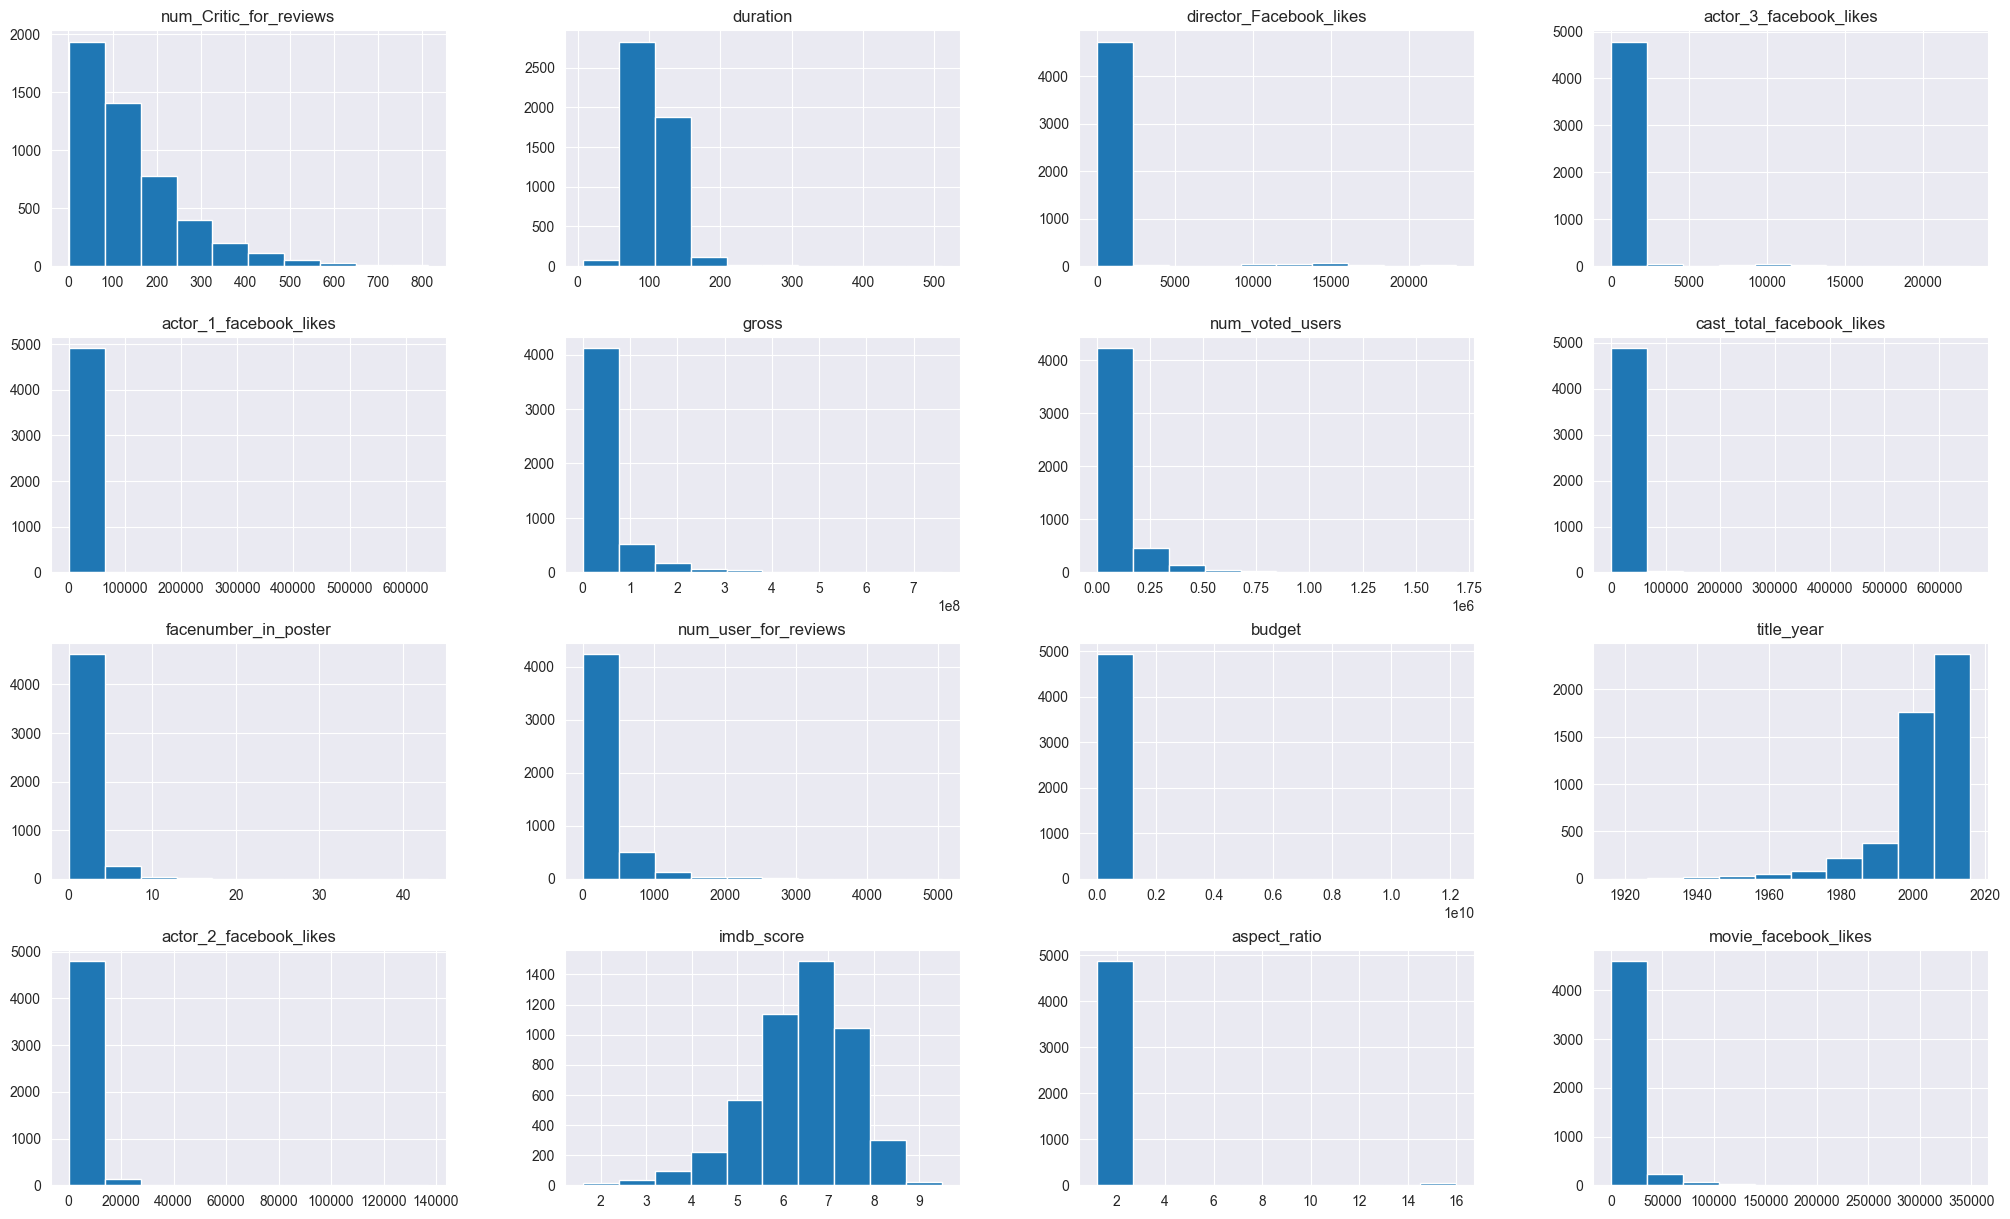

In [309]:
movies_data.hist(figsize=(25, 15))

`num_Critic_for_reviews`

Среднее значение — 139.6, медиана — 110, минимум — 1, максимум — 813.

В среднем фильмы получают примерно 100 отзывов от критиков, но при этом есть фильмы, которые критики практически не рассматривали (1 отзыв) и фильмы, которым критики уделяли особо много внимания (813 отзывов).

`duration`

Среднее — 107 минут, медиана — 103, минимум - 7 минут, максимум - 511 минут.

В целом фильмы идут около 1.5 часов, но при этом есть и особо короткие фильмы, и очень длинные.

`director_facebook_likes`

Среднее — 672, медиана — 49, минимум - 0, максимум - 23 000.

В целом режиссеры получают небольшое количество лайков, но при этом есть и особо популярные.

`actor_3_facebook_likes`

Среднее — 638, медиана — 372, минимум - 0, максимум - 23 000.

Актеры из `actor_3_facebook_likes` более популярны в социальных сетях, чем режиссеры. При этом есть как и малоизвестные актеры, так и особо популярные.

`actor_2_facebook_likes`
Среднее — 1634, медиана — 595, минимум - 0, максимум - 137 000.

Актеры из этого столбца более популярны, чем актеры из `actor_3_facebook_likes` и режиссеры. При этом есть как и малоизвестные актеры, так и особо популярные.

`actor_1_facebook_likes`

Среднее — 6487, медиана — 989, минимум - 0, максимум - 640 000.
В среднем главные актеры более популярны, чем другие актеры и режиссеры. При этом есть как и малоизвестные актеры, так и особо популярные.

`num_voted_users`

Среднее — 82 941, медиана — 34 442, минимум - 5, максимум - 1.69 млн.

Есть сильная правосторонняя асимметрия. В среднем фильмы получают около 35 тысяч голосов, но есть и особо популярные фильмы.

`cast_total_facebook_likes`

Среднее — 9615, медиана — 3089, минимум - 0, максимум - 656 730.

Есть сильная правосторонняя асимметрия. Есть особо популярные составы, есть малоизвестные.

`facenumber_in_poster`

Среднее — 1.36, медиана — 1, минимум - 0, максимум - 43.

В среднем на постере изображен один человек, но есть постеры с большим составом.

`num_user_for_reviews`

Среднее — 271, медиана — 156, минимум - 1, максимум - 5060.

В среднем фильмы получают около 150-200 отзывов, но есть и особо обсуждаемые картины.

`title_year`

Среднее — 2002.6, медиана — 2005, от 1916 до 2016.

Большая часть фильмов вышла в начале двухтысячных, но есть и более старые, и более новые фильмы.

`imdb_score`

Среднее — 6.43, медиана — 6.5, минимум - 1.6, максимум - 9.5.

В целом фильмы получают оценку около 6-7 баллов, но есть и плохие картины с низкими оценками, и высоко оцененные картины с высокими оценками.

`aspect_ratio`

Среднее — 2.21, медиана — 2.0, минимум - 1.18, максимум - 16.

В целом картины обладают стандартным соотношением сторон, но есть картины с нестандартным соотношением.

`movie_facebook_likes`

Среднее — 7432, медиана — 162, минимум - 0, максимум - 349 000.

В целом картины собирают немного лайков в социальных сетях, но есть особо популярные фильмы.

`real_domestic_gross`

Среднее — 67.9 млн, медиана — 31.4 млн, минимум - 164 тыс., максимум - 3.43 млрд.

Есть фильмы, собравшие маленькие суммы в прокате, и есть фильмы, которые имеют особо большие кассовые сборы.

`real_budget`

Среднее — 48.9 млн, медиана — 24.6 млн, минимум - 284 тыс., максимум - 14.5 млрд.

Есть как дешевые фильмы, так и особо дорогие.

### Обработка выбросов

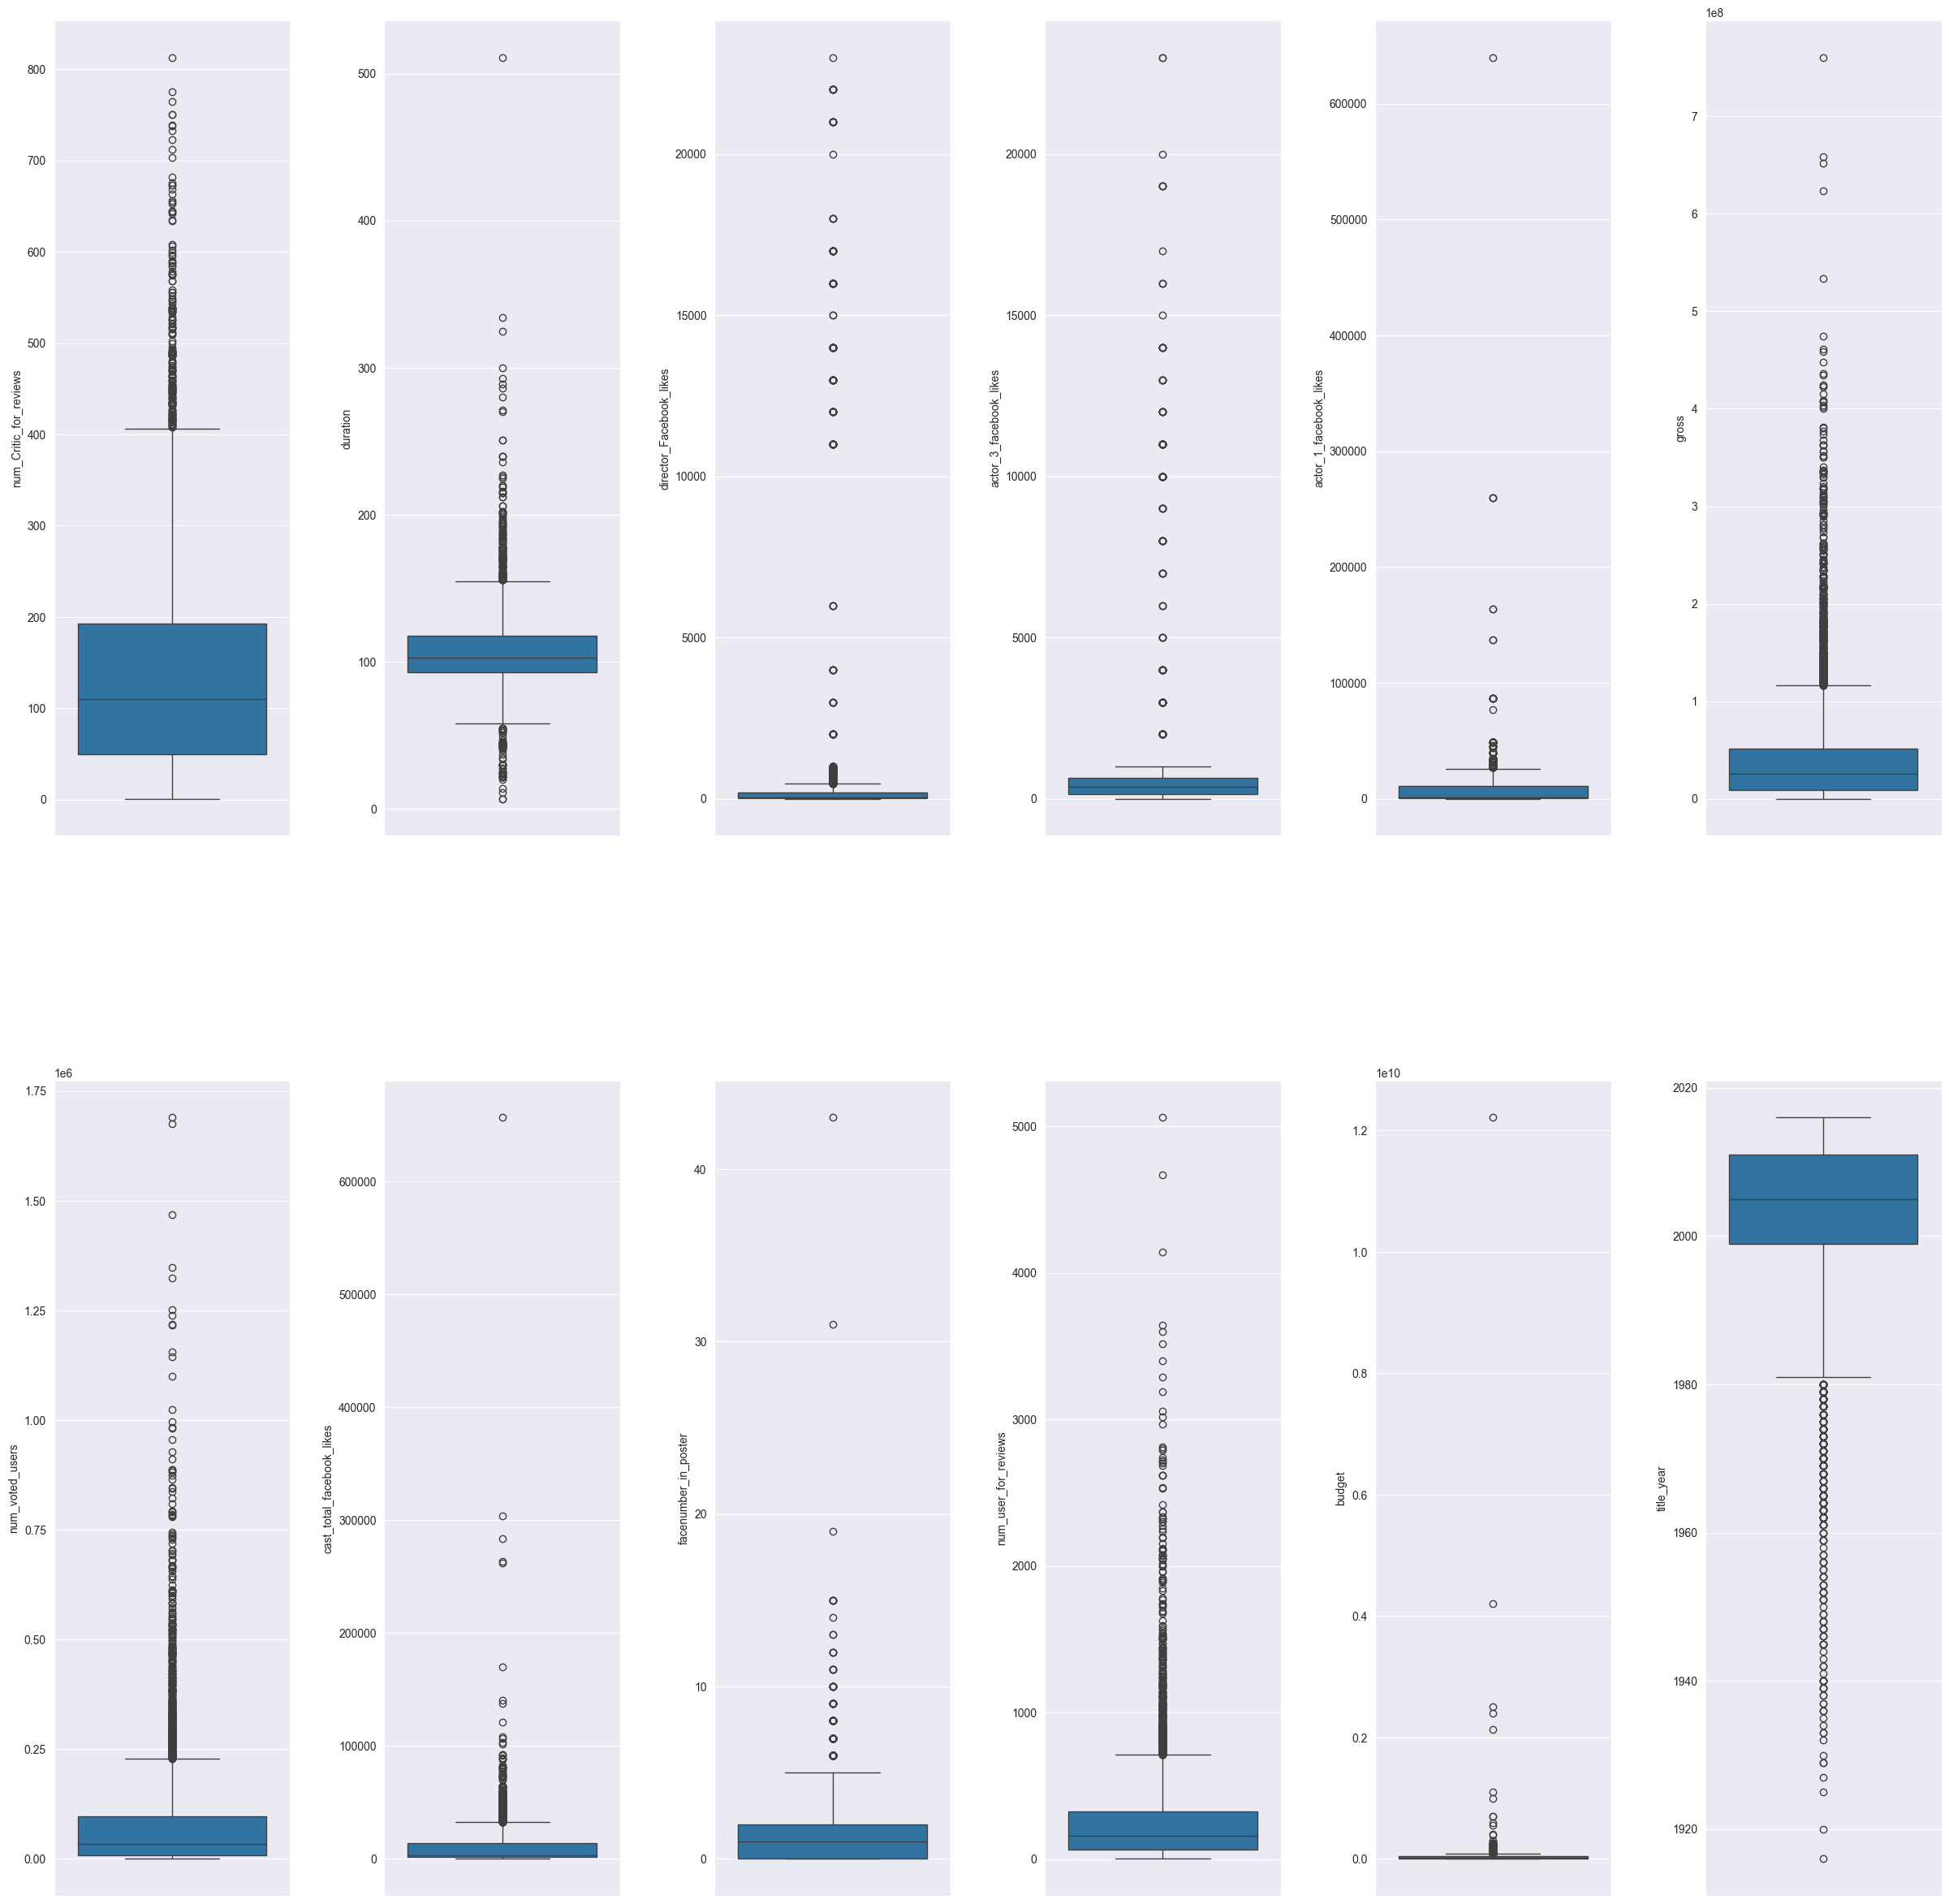

In [310]:
fig, axs = plt.subplots(2, 6, figsize=(30, 30))
plt.subplots_adjust(wspace=0.4, hspace=0.3)
ax_flatten = axs.flatten()
numeric_columns = movies_data.select_dtypes(include="number").columns
for i in range(len(ax_flatten)):
    sns.boxplot(movies_data, y = movies_data[numeric_columns[i]], ax = ax_flatten[i])

Прежде всего заметим, что значения в `facenumber_in_poster`, `title_year`, `imdb_score` точно являются аномальными и их не стоит удалять.

Так, на некоторых особых постерах действительно может быть изображено много персонажей, хотя на большинстве из них и изображены только несколько основных героев.

В `title_year` содержится информация и о некоторых более старых фильмах 20 века.

В `imdb_score` содержится информация не только о качественных фильмах, но и о плохих с низкими оценками.

Для прочих величин исследуем выбросы отдельно в их взаимосвязи с другими величинами.

#### Рецензии критиков

Проанализируем, необходимо ли удалять выбросы для столбца, соответствующему числу критических рецензий.

<Axes: xlabel='movie_facebook_likes', ylabel='num_Critic_for_reviews'>

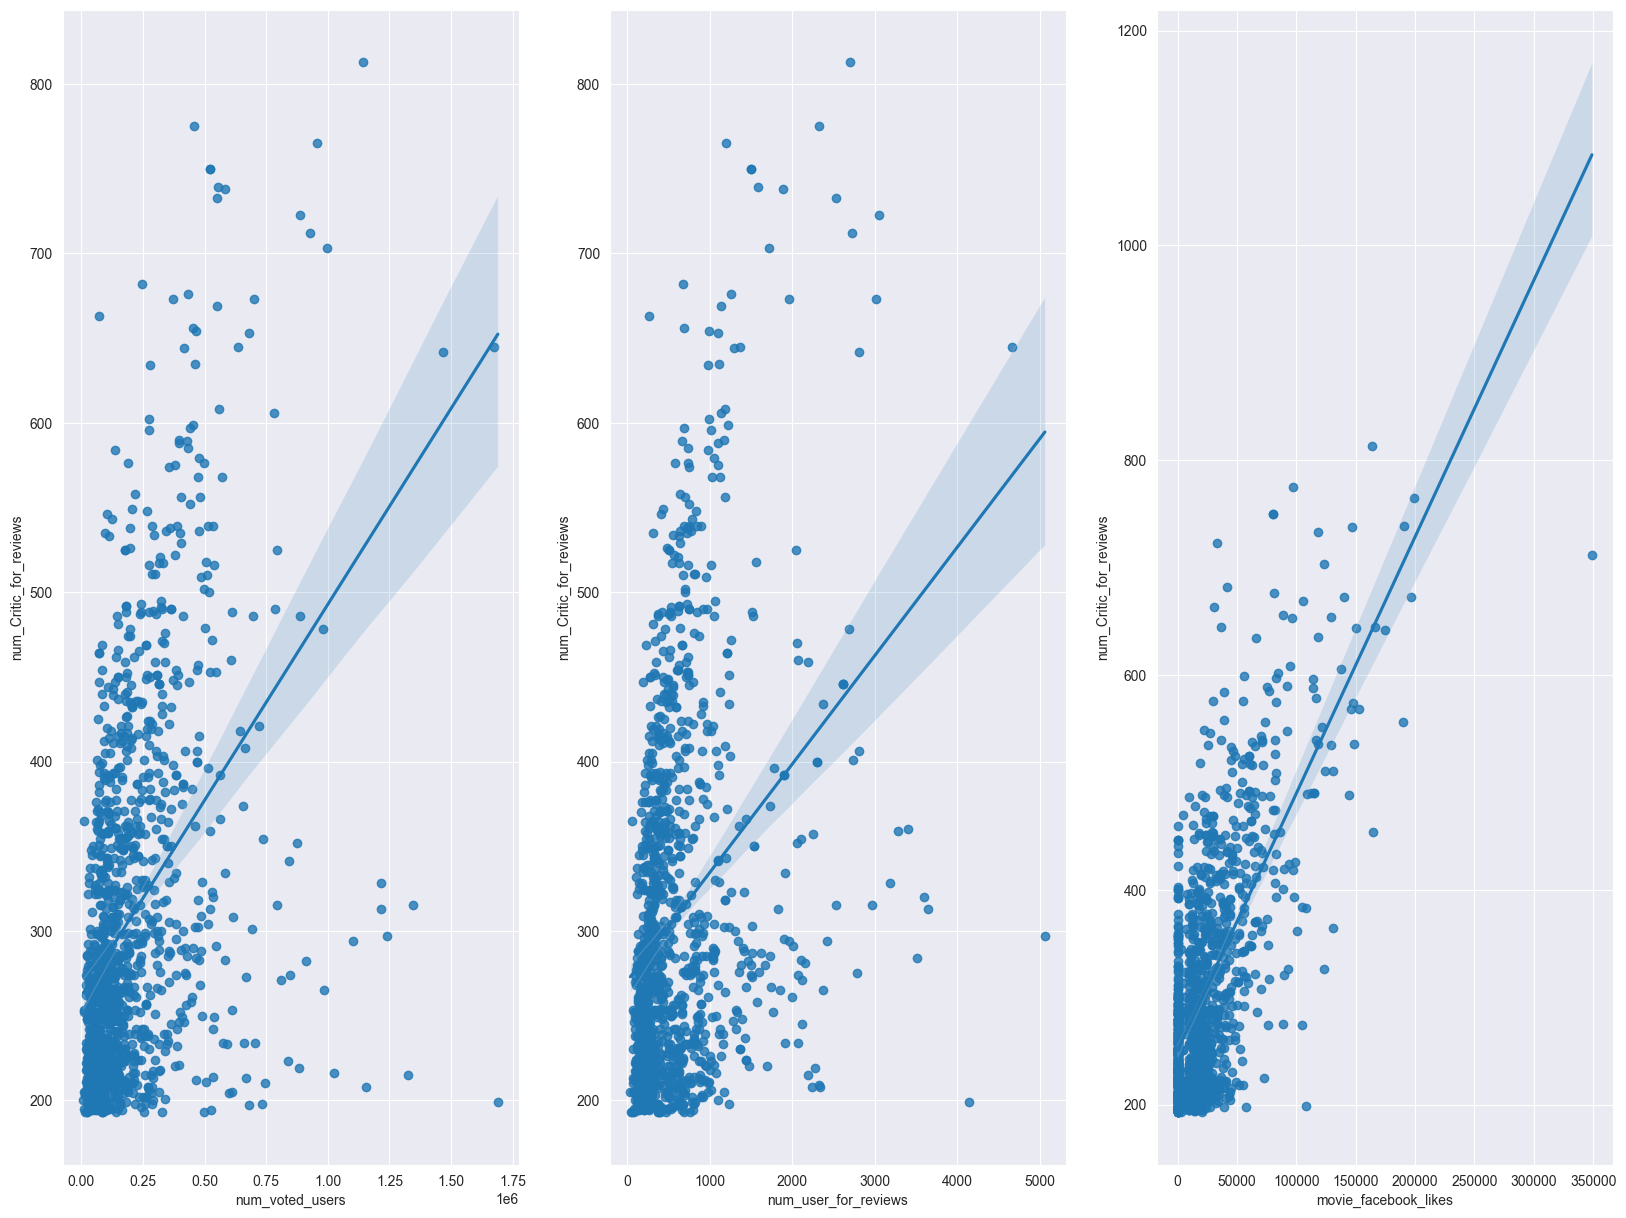

In [311]:
many_critics_reviews = movies_data[movies_data["num_Critic_for_reviews"] >= movies_data["num_Critic_for_reviews"].quantile(0.75)]

fig, ax = plt.subplots(1, 3, figsize=(20, 15))
sns.regplot(many_critics_reviews, y = many_critics_reviews["num_Critic_for_reviews"],x=many_critics_reviews["num_voted_users"], ax=ax[0])
sns.regplot(many_critics_reviews, y = many_critics_reviews["num_Critic_for_reviews"], x=many_critics_reviews["num_user_for_reviews"], ax=ax[1])
sns.regplot(many_critics_reviews, y = many_critics_reviews["num_Critic_for_reviews"], x=many_critics_reviews["movie_facebook_likes"], ax=ax[2])



Можно заметить, что количество критических рецензий растет с увеличением числа проголосовавших пользователей и увеличением популярности фильма в социальных сетях. Фильмы с большим числом критических рецензий являются особо обсуждаемыми фильмами в обществе.

#### Продолжительность фильма

Заметим, что в столбце `genres` жанры фильма указаны в формате списка, где первый указанный в списке жанр - основной, а последний жанр - самый незначительный.

Для того, чтобы оценить, какой жанр фильма преобладает среди данных, будем рассматривать только первый жанр из списка для того, чтобы лучше понять характеристики фильма.

<Axes: xlabel='title_year', ylabel='duration'>

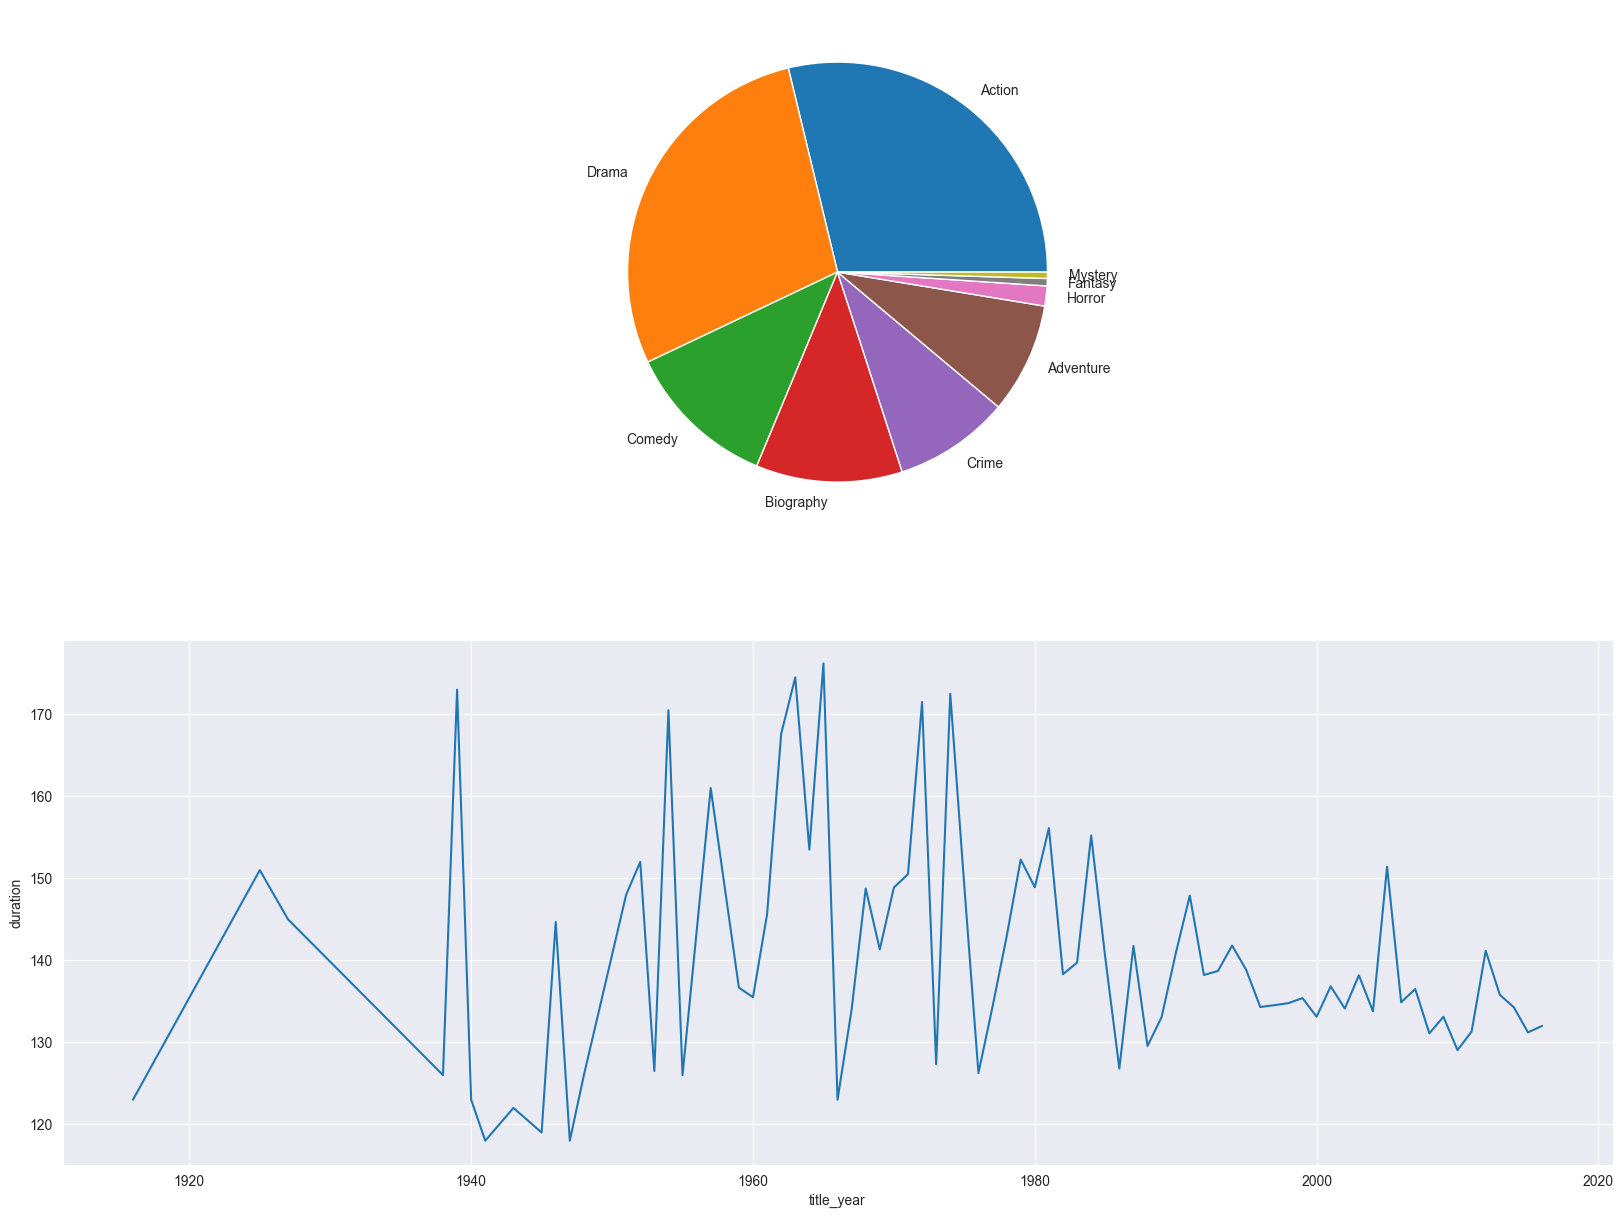

In [312]:
fig, ax = plt.subplots(2, 1, figsize=(20, 15))

long_films = movies_data[movies_data["duration"] >= movies_data["duration"].quantile(0.75)]

long_films_genres = long_films["genres"].str.split('|').str[0]
long_films_genres_count = long_films_genres.value_counts().head(9)

ax[0].pie(long_films_genres_count.values, labels=long_films_genres_count.index)
sns.lineplot(long_films, x="title_year", y="duration", ax=ax[1], errorbar=None)

Заметим, что самые популярные жанры для долгих фильмов - экшен, драма и комедия. Такие фильмы обычно имеют больший хронометраж из-за более сложного сюжета и большого количества эпических событий.

Фильмы с длинным хронометражном характерны для 1940-1960 годов. Это объясняется художественными предпочтениями режиссеров того времени, стремившихся к неспешному повествованию.

Таким образом, длинные фильмы - это аномальные значения и их не стоит удалять.

<Axes: xlabel='title_year', ylabel='duration'>

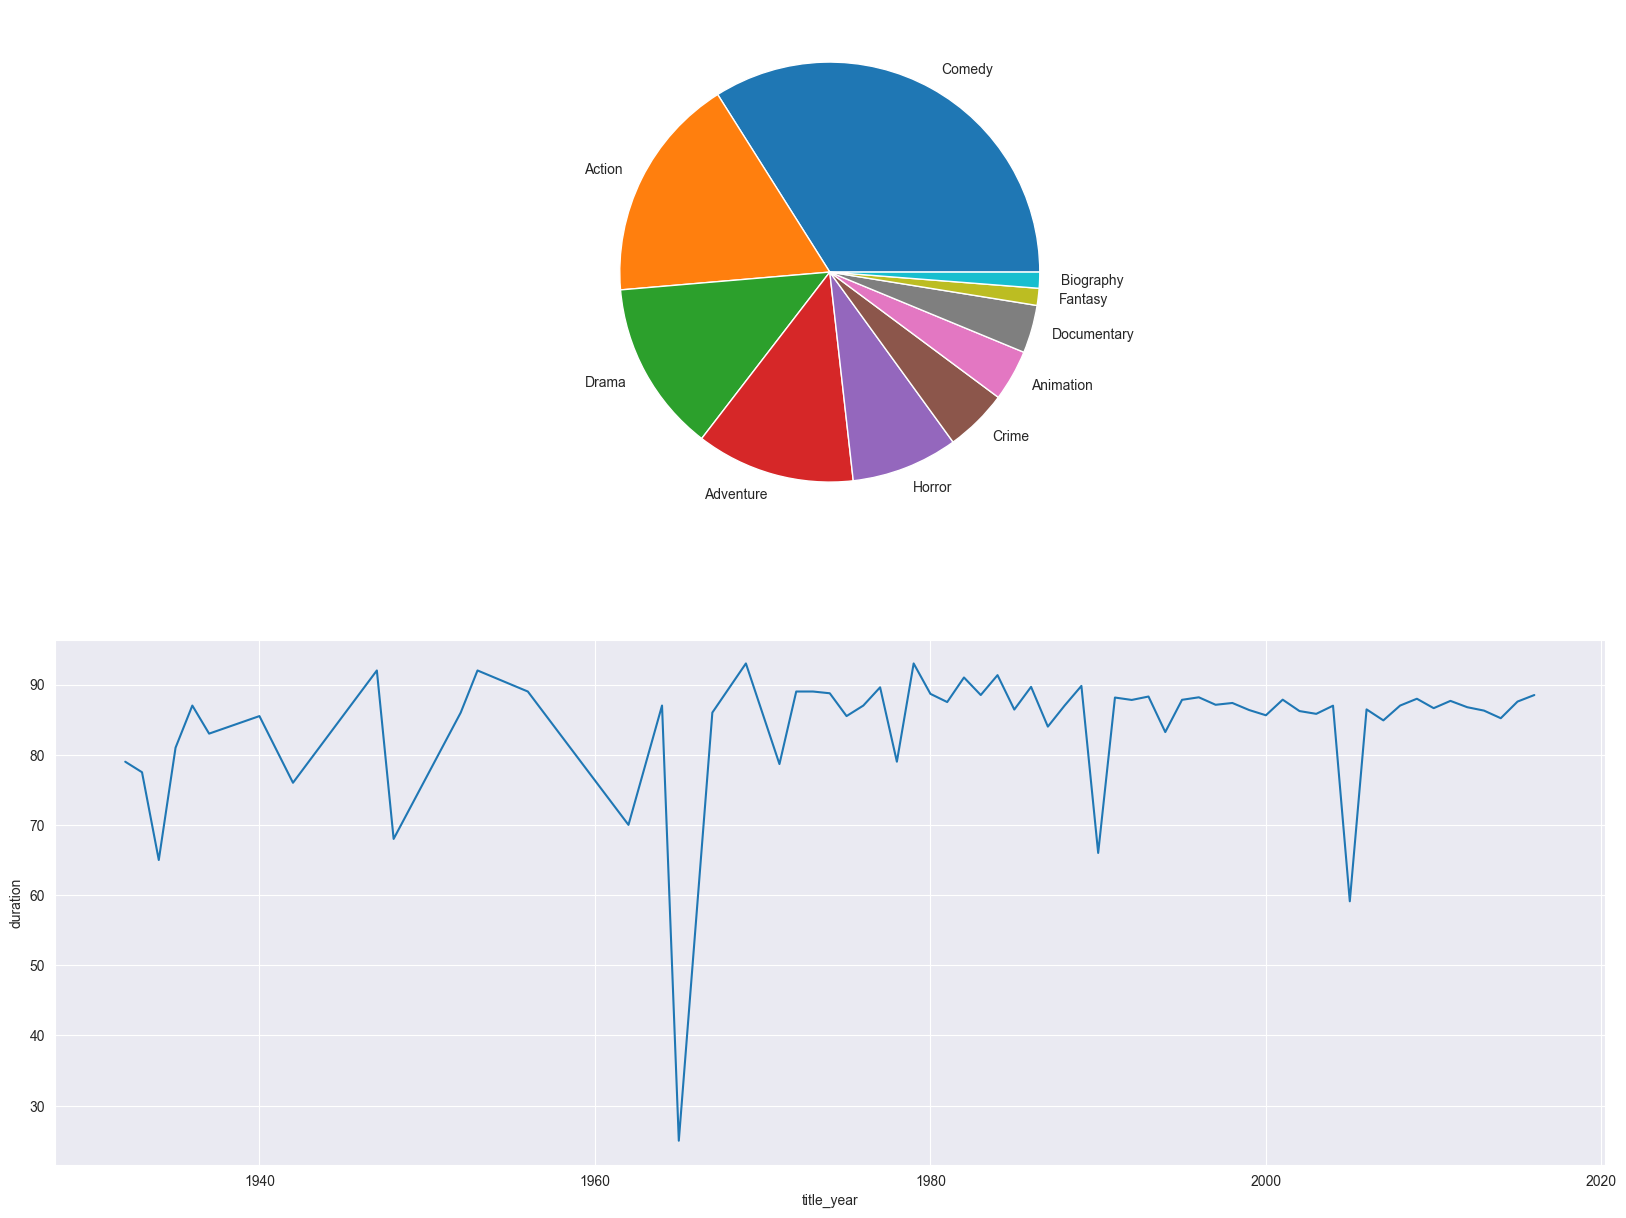

In [313]:
fig, ax = plt.subplots(2, 1, figsize=(20, 15))

short_films = movies_data[movies_data["duration"] <= movies_data["duration"].quantile(0.25)]
short_films_genres = short_films["genres"].str.split('|').str[0]
short_films_genres_count = short_films_genres.value_counts().head(10)
ax[0].pie(short_films_genres_count, labels=short_films_genres_count.index)

sns.lineplot(short_films, x="title_year", y="duration", ax=ax[1], errorbar=None)


Заметим, что преобладающие жанры для коротких фильмов - комедия, экшен, драма, приключение, хоррор.

Эти данные являются аномальными значениями, так как не всем фильмам необходим большой хронометраж, например, комедиям или хоррорам. Кроме того, могут быть включены короткометражные драматические фильмы.

### Популярность режиссеров

In [314]:
popular_directors = movies_data[movies_data["director_Facebook_likes"] >=movies_data["director_Facebook_likes"].quantile(0.75) ]
popular_directors["Director_Name"].unique()

array(['Gore Verbinski', 'Christopher Nolan', 'Andrew Stanton',
       'David Yates', 'Marc Forster', 'Rob Marshall', 'Marc Webb',
       'Peter Berg', 'Colin Trevorrow', 'Shane Black', 'Tim Burton',
       'Brett Ratner', 'Joseph Kosinski', 'John Lasseter',
       'Martin Campbell', 'McG', 'J.J. Abrams', 'Baz Luhrmann',
       'Steven Spielberg', 'Justin Lin', 'Roland Emmerich', 'Jon Favreau',
       'Martin Scorsese', 'Rob Cohen', 'David Ayer', 'Tom Shadyac',
       'Doug Liman', 'Stephen Sommers', 'Rupert Sanders', 'Matt Reeves',
       'Roland Joffé', 'Brad Bird', 'Dean DeBlois', 'James Gunn',
       'David Fincher', 'Matthew Vaughn', 'Francis Lawrence',
       'Jon Turteltaub', 'Wolfgang Petersen', 'Alan Taylor', 'Shawn Levy',
       'George Miller', 'Ron Howard', 'Jonathan Liebesman',
       'Joe Johnston', 'Joe Wright', 'Edward Zwick', 'Alex Proyas',
       'Richard Donner', 'Jon M. Chu', 'Peter Weir', 'Bill Condon',
       'Louis Leterrier', 'Paul Greengrass', 'Peyton Reed',
  

Среди режиссеров очень много особо известных и успешных - Кристофер Нолан, Стивен Спилберг и Мартин Скорсезе.

<Axes: xlabel='director_Facebook_likes', ylabel='num_voted_users'>

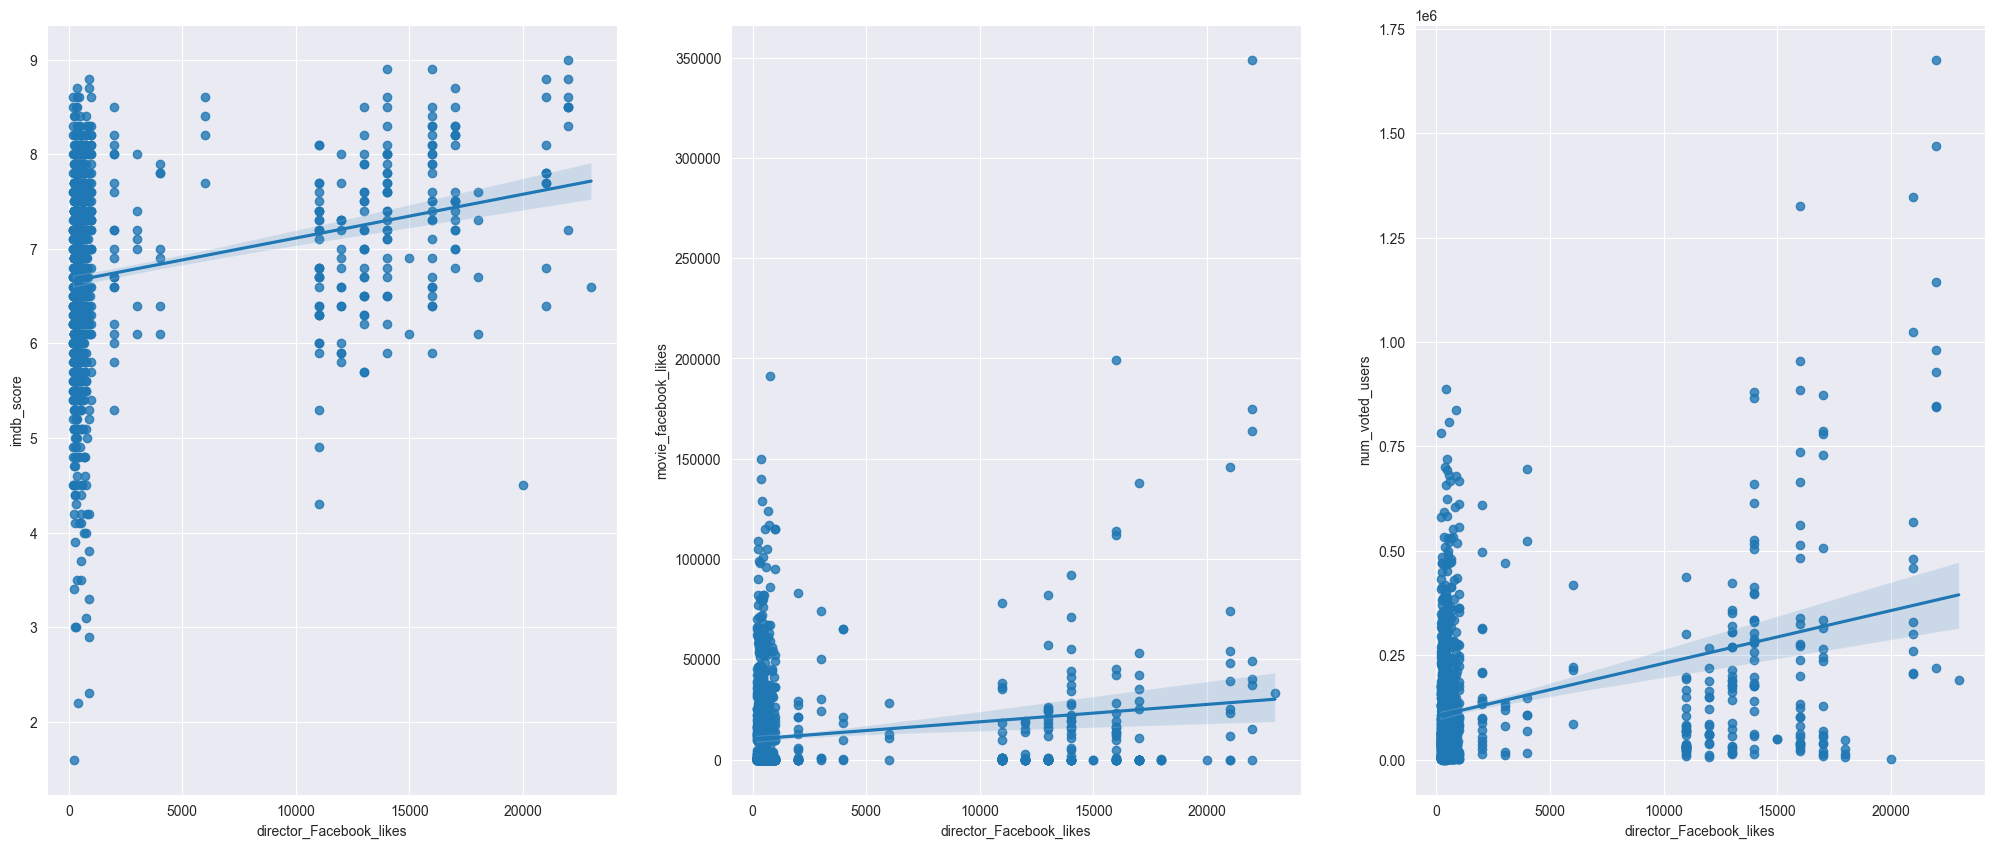

In [315]:
fig, ax = plt.subplots(1, 3, figsize=(25, 10))

sns.regplot(popular_directors, x="director_Facebook_likes", y="imdb_score", ax=ax[0])
sns.regplot(popular_directors, x="director_Facebook_likes", y="movie_facebook_likes", ax=ax[1])
sns.regplot(popular_directors, x="director_Facebook_likes", y="num_voted_users", ax=ax[2])

Режиссеры, имеющие большое количество лайков в Фейсбуке, в среднем имеют более высокие оценки своих фильмов на IMDB.

Их фильмы более обсуждаемы в сети, так как количество пользователей, оставивших оценки, увеличивается с ростом числа лайков постов режиссеров в Фейсбуке.

Таким образом, известные режиссеры это аномальные значения, и их не стоит удалять из датасета.

#### Популярность актерского состава

In [316]:
popular_actors = movies_data[(movies_data["actor_1_facebook_likes"] >= 5000) &
                            (movies_data["actor_2_facebook_likes"] >= 5000) &
                            (movies_data["actor_3_facebook_likes"] >= 5000)]

popular_actors[["actor_1_name", "actor_2_name", "actor_3_name"]]

,actor_1_name,actor_2_name,actor_3_name
3,Tom Hardy,Christian Bale,Joseph Gordon-Levitt
8,Chris Hemsworth,Robert Downey Jr.,Scarlett Johansson
9,Alan Rickman,Daniel Radcliffe,Rupert Grint
17,Chris Hemsworth,Robert Downey Jr.,Scarlett Johansson
27,Robert Downey Jr.,Scarlett Johansson,Chris Evans
...,...,...,...
3429,Joseph Gordon-Levitt,Chloë Grace Moretz,Zooey Deschanel
3431,Channing Tatum,Alex Pettyfer,Matthew McConaughey
3571,J.K. Simmons,Bradley Cooper,Olivia Wilde
4079,Johnny Depp,Alan Rickman,Anne Hathaway


Заметим, особо популярные актеры в социальных сетях это действительно известные актеры, поэтому данные об их популярности являются аномальными значениями и их не стоит удалять.

### Фильмы, популярные у пользователей

<Axes: xlabel='num_voted_users', ylabel='movie_facebook_likes'>

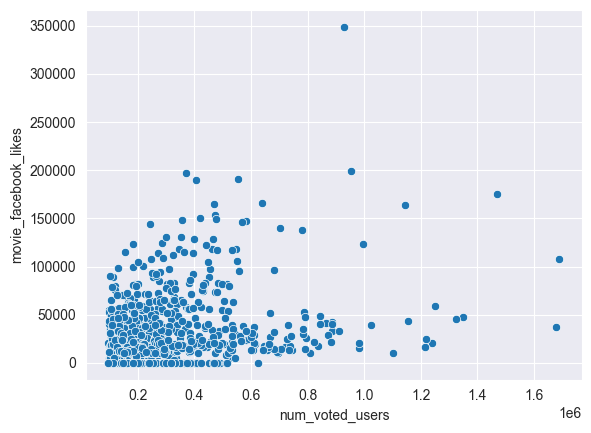

In [317]:
popular_movies = movies_data[movies_data["num_voted_users"] >= movies_data["num_voted_users"].quantile(0.75)]

sns.scatterplot(popular_movies, x="num_voted_users", y="movie_facebook_likes")

С увеличением числа пользователей, оставивших оценку, растет популярность фильма в социальных сетях. Значит, фильмы с большим числом оценок являются аномальными и их не стоит удалять

### Число пользователей, оставивших рецензии

<Axes: xlabel='num_user_for_reviews', ylabel='num_voted_users'>

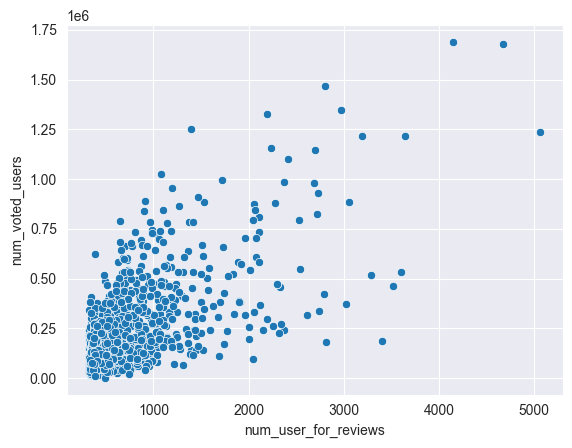

In [318]:
movies_with_many_reviews = movies_data[movies_data["num_user_for_reviews"] >= movies_data["num_user_for_reviews"].quantile(0.75)]

sns.scatterplot(movies_with_many_reviews, x="num_user_for_reviews", y="num_voted_users")

Заметим, что у фильмов с большим числом оценок большое количество отзывов. Вероятно, что это просто особо популярные фильмы и данные, содержащую информацию о них, удалять не нужно.

In [319]:
movies_data.columns

Index(['color', 'Director_Name', 'num_Critic_for_reviews', 'duration',
       'director_Facebook_likes', 'actor_3_facebook_likes', 'actor_2_name',
       'actor_1_facebook_likes', 'gross', 'genres', 'actor_1_name',
       'num_voted_users', 'cast_total_facebook_likes', 'actor_3_name',
       'facenumber_in_poster', 'num_user_for_reviews', 'language', 'country',
       'content_rating', 'budget', 'title_year', 'actor_2_facebook_likes',
       'imdb_score', 'aspect_ratio', 'movie_facebook_likes'],
      dtype='object')

### Исследование с помощью  визуального EDA

<Axes: >

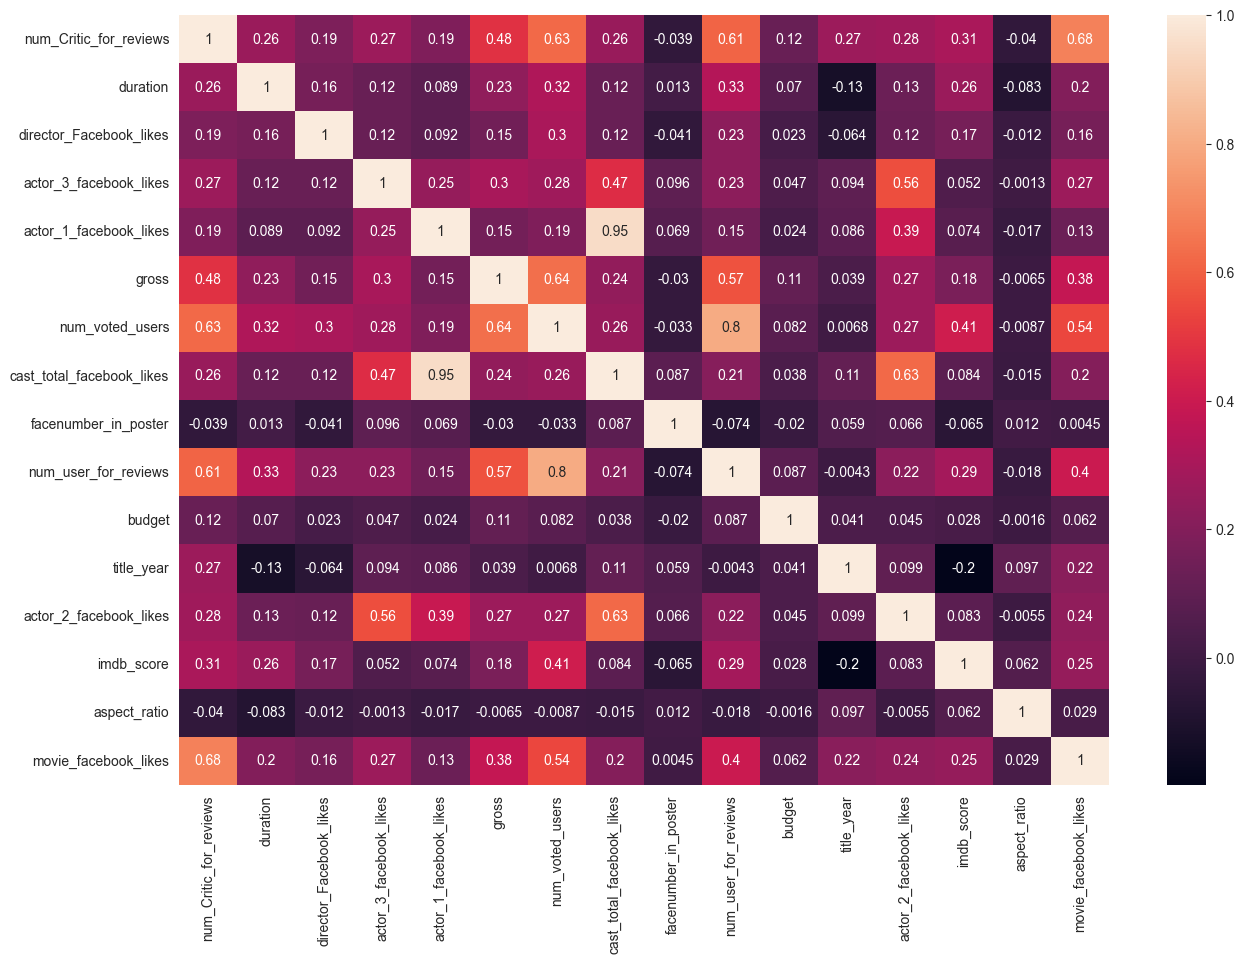

In [320]:
plt.figure(figsize=(15, 10))
sns.heatmap(movies_data[numeric_columns].corr(), annot=True)

Признаки с сильной корреляцией:

* `actor_1_facebook_likes` и `cast_total_facebook_likes`

* `num_voted_users` и `num_user_for_reviews`

* `budget` и `real_budget`

Признаки со средней корреляцией:

* `num_critic_for_reviews` и `num_voted_users`

* `num_critic_for_reviews` и `num_user_for_reviews`

* `num_critic_for_reviews` и `movie_facebook_likes`

* `duration` и `num_votes_users`

* `duration` и `num_user_for_reviews`

* `director_facebook_likes` и `num_voted_users`

* `actor_3_facebook_likes` и `cast_total_facebook_likes`

* `actor_3_facebook_likes` и `actor_2_facebook_likes`

* `actor_1_facebook_likes` и `actor_2_facebook_likes`

* `num_voted_users` и `imdb_score`

* `num_voted_users` и `movie_facebook_likes`

* `num_voted_users` и `real_domestic_gross`

* `cast_total_facebook_likes` и `actor_2_facebook_likes`

* `num_user_for_reviews` и `movie_facebook_likes`

* `title_year` и `real_domestic_gross`

* `real_domestic_gross` и `gross`


#### 1. Как распределены рейтинги фильмов (IMDb score)?


<Axes: xlabel='imdb_score', ylabel='Count'>

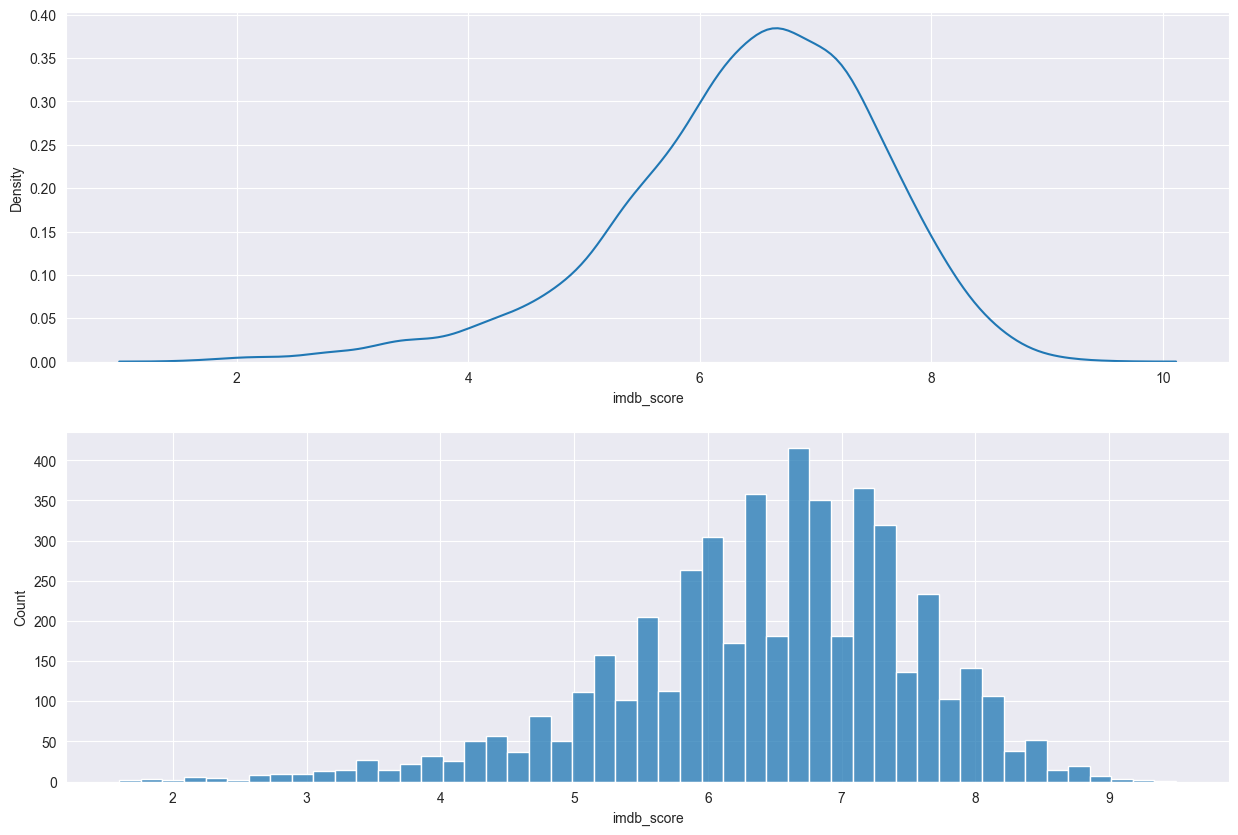

In [321]:
fig, ax = plt.subplots(2, 1, figsize=(15, 10))
sns.kdeplot(movies_data["imdb_score"], ax=ax[0])
sns.histplot(movies_data["imdb_score"], ax=ax[1])

Распределение рейтингов фильмов близко к нормальному распределению.


#### 2. Существует ли зависимость между бюджетом фильма и его кассовыми сборами?


In [322]:
# sns.regplot(movies_data, x="real_domestic_gross", y="real_budget")

Прямая регрессии имеет очень малый угол наклона - можно сказать, что сборы фильма не зависят от бюджета фильма.


#### 3. Какие жанры встречаются чаще всего?


Text(0.5, 1.0, 'Множественные жанры')

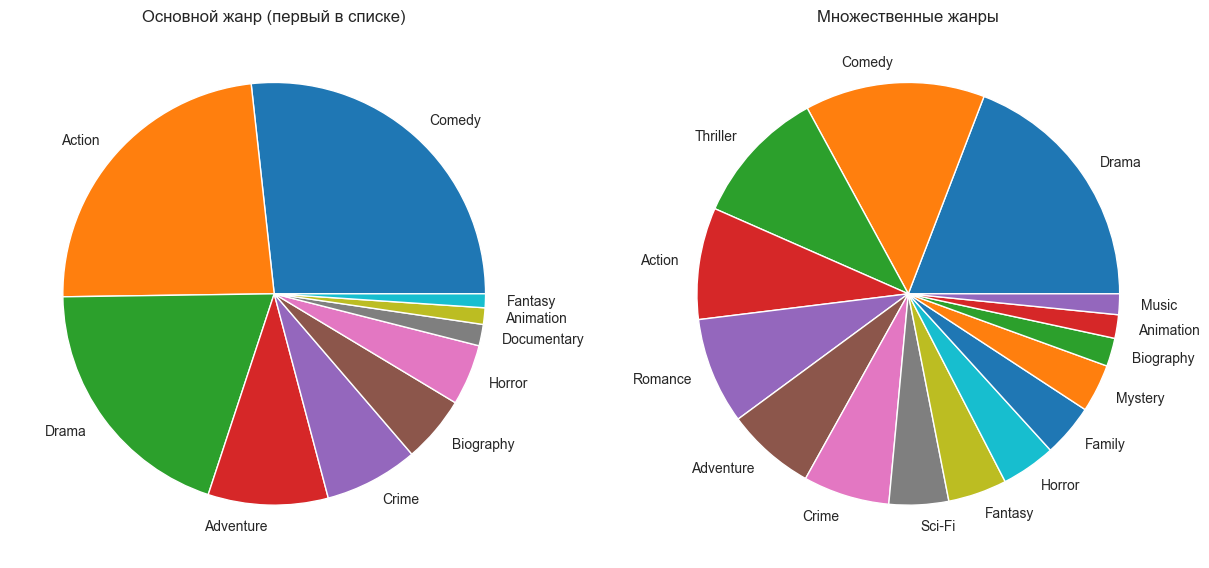

In [323]:
fig, ax = plt.subplots(1, 2, figsize=(15, 15))

main_genres = movies_data["genres"].str.split('|').str[0]
main_genres_count = main_genres.value_counts().head(10)

all_genres = movies_data["genres"].str.split('|').explode()
all_genres_count = all_genres.value_counts().head(15)


ax[0].pie(main_genres_count.values, labels=main_genres_count.index)
ax[1].pie(all_genres_count.values, labels=all_genres_count.index)

ax[0].set_title("Основной жанр (первый в списке)")
ax[1].set_title("Множественные жанры")

Как основные жанры, комедия, экшен и драма - наиболее популярные жанры.

С учетом множественных жанров наиболее популярными являются драма, комедия и триллер.

#### 4. Влияет ли количество проголосовавших пользователей на итоговый рейтинг?

<Axes: xlabel='num_voted_users', ylabel='imdb_score'>

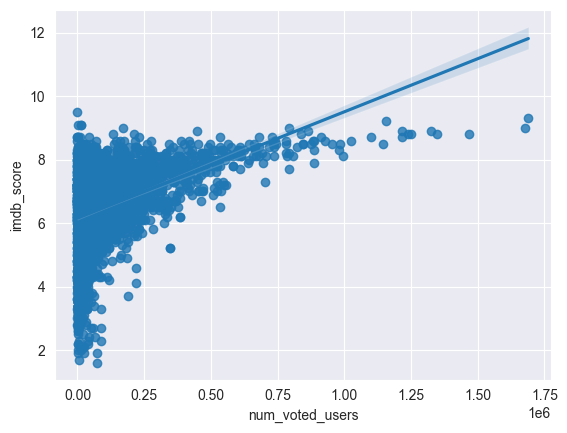

In [324]:
sns.regplot(movies_data, x="num_voted_users", y="imdb_score")

С ростом числа проголосовавших пользователей рейтинг выше. Возможно, что более качественные фильмы привлекают большее число зрителей.


#### 5. Есть ли связь между суммарными лайками актёров в Facebook и рейтингом фильма?


<Axes: xlabel='cast_total_facebook_likes', ylabel='imdb_score'>

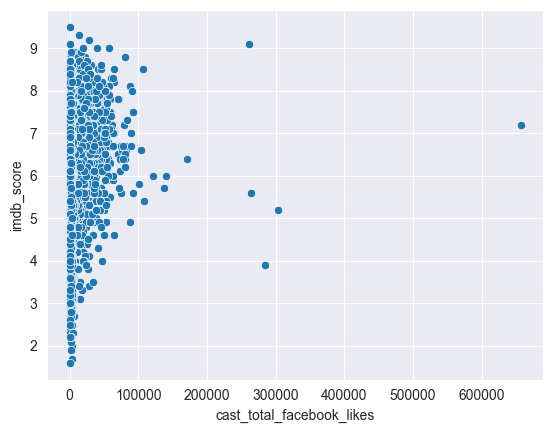

In [325]:
sns.scatterplot(movies_data, x="cast_total_facebook_likes", y="imdb_score")

Актерский состав высоко оцененных фильмов имеет большую популярность в социальных сетях, чем актерский состав низко оцененных фильмов. При этом много фильмов с популярным актерским составом имеют оценки ниже, чем фильмы с более высокими оценками, но менее популярным актерским составом.

Можно сказать, что популярность актерского состава может повысить шансы на высокую оценку фильма, но не является основным фактором.


#### 6. Как изменялся средний бюджет фильмов по годам?


<Axes: xlabel='title_year', ylabel='budget'>

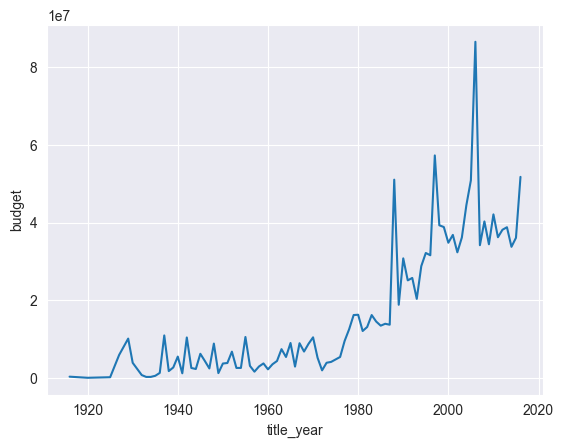

In [326]:
sns.lineplot(movies_data, x="title_year", y="budget", errorbar=None)

Можно заметить, что в 1920-1980 годы бюджеты фильмов оставались примерно в одном и том же диапазоне до 15 млн. долларов.

С 1980 годов бюджеты для фильмов стали существенно возрастать, превышая 50 млн. долларов.

####  7. Какие страны лидируют по количеству произведённых фильмов?

<Axes: xlabel='country'>

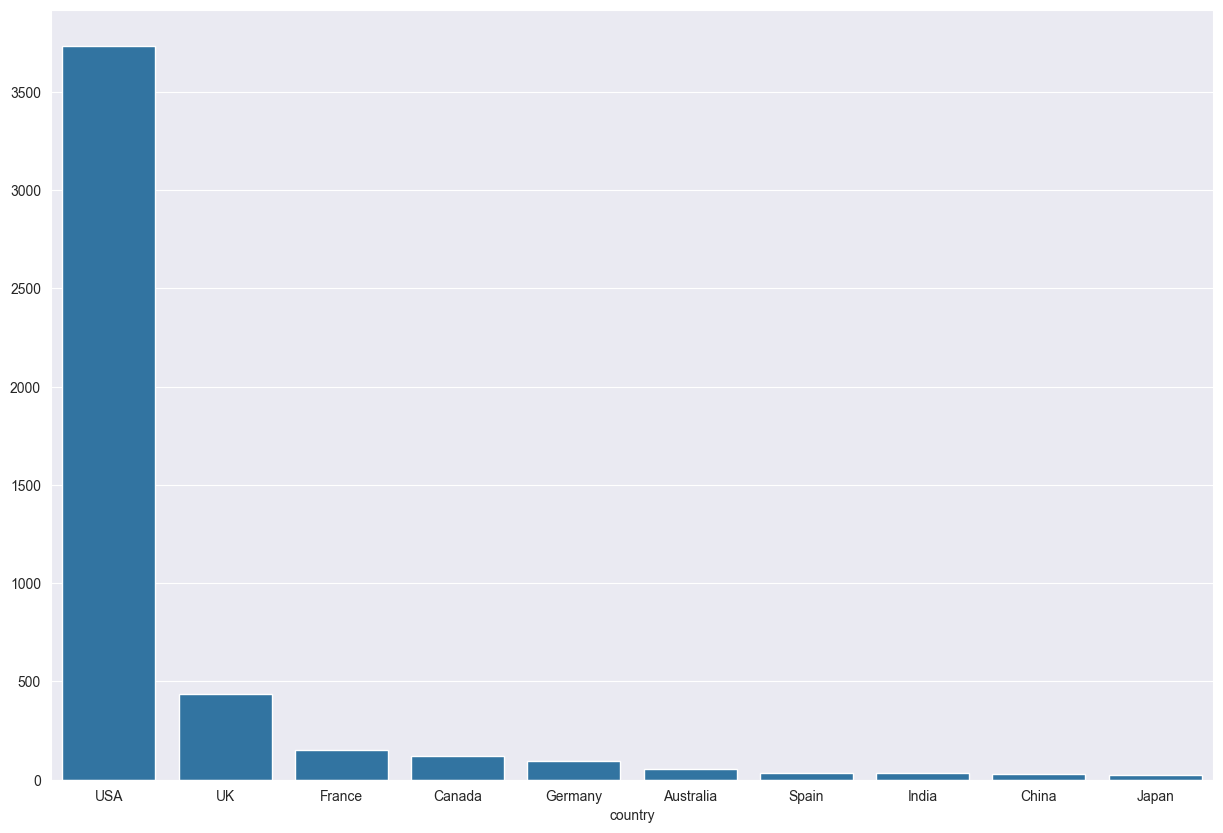

In [327]:
countries_films = movies_data["country"].value_counts().head(10)
plt.figure(figsize=(15, 10))
sns.barplot(x=countries_films.index, y=countries_films.values)

США абсолютно лидирует в сфере кинопроизводства, свыше 3500 фильмов сняты в США.

Около 500 фильмов были сняты Великобританией и около 250 - Францией.


#### 8. Каково распределение длительности фильмов?

<Axes: xlabel='duration', ylabel='Count'>

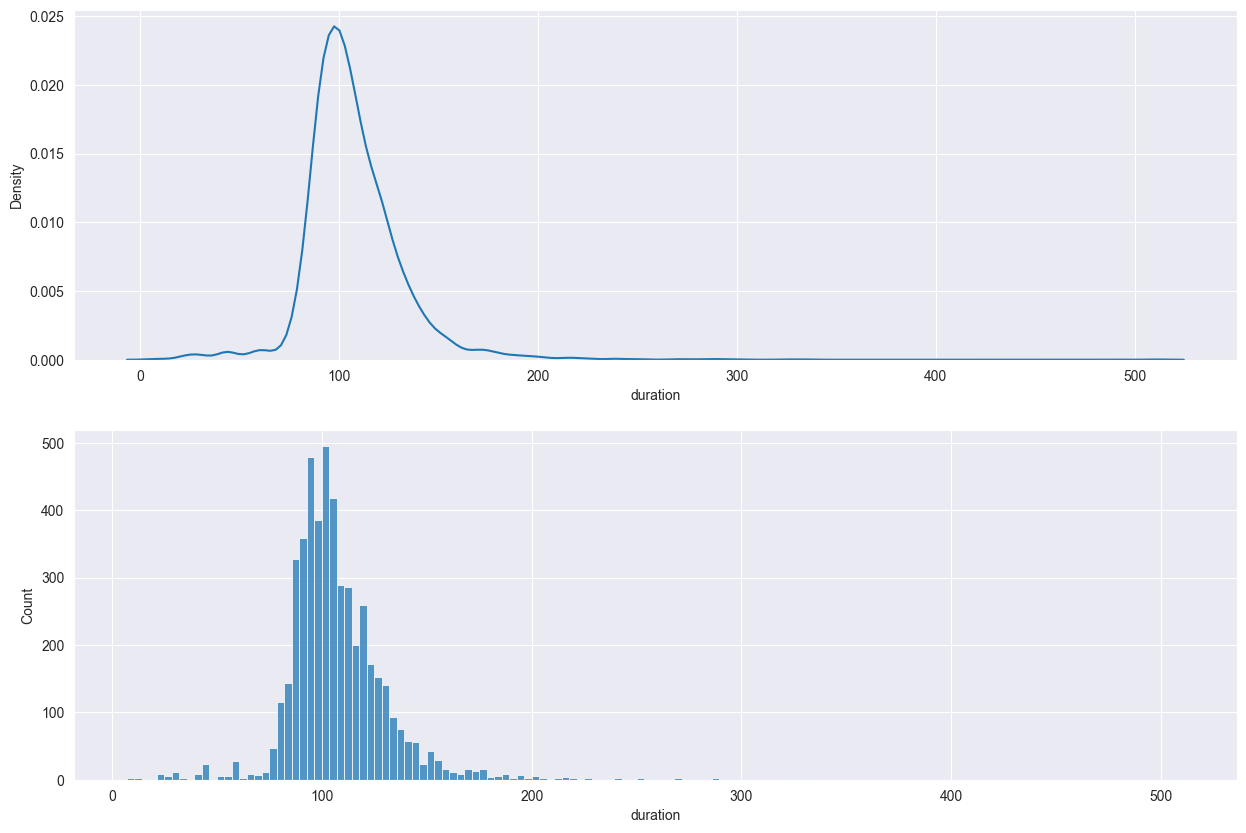

In [328]:
fig, ax = plt.subplots(2, 1, figsize=(15, 10))
sns.kdeplot(movies_data["duration"], ax=ax[0])
sns.histplot(movies_data["duration"], ax=ax[1])

Распределение длительности фильмов близко к нормальному.

Стоит отметить, что существуют особо длинные и короткие фильмы, которые выделяются из общего распределения.


#### 9. Различаются ли кассовые сборы в зависимости от возрастного рейтинга?

<Axes: xlabel='content_rating', ylabel='gross'>

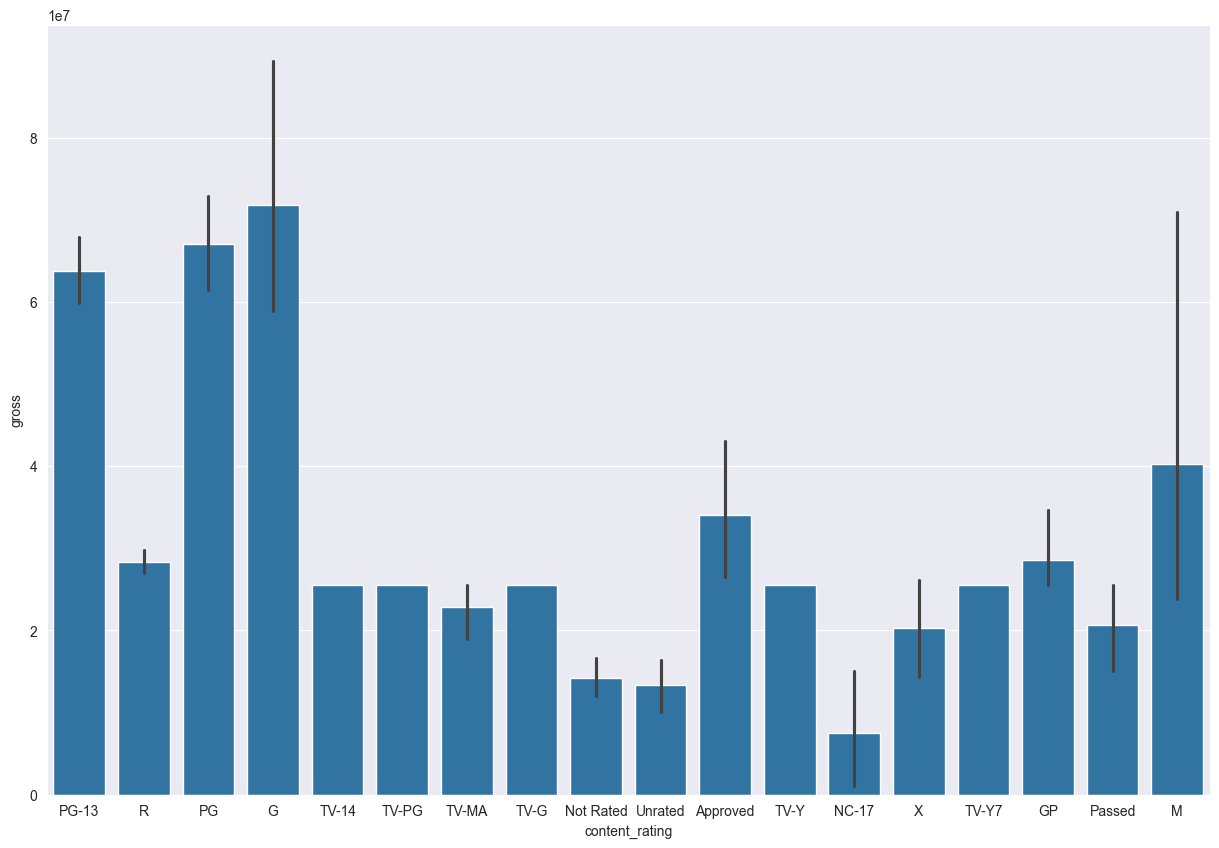

In [329]:
plt.figure(figsize=(15, 10))
sns.barplot(movies_data, x="content_rating", y="gross")

Можно заметить, что фильмы с рейтингами PG-13, PG и G имеют значительно большие кассовые сборы, чем с прочими рейтингами.

Фильмы с рейтингами R, NC-17, M имеют гораздо меньшие кассовые сборы.

Возможно, это связно с тем, что широкая аудитория предпочитает легкие семейные фильмы.

In [330]:
movies_data.columns

Index(['color', 'Director_Name', 'num_Critic_for_reviews', 'duration',
       'director_Facebook_likes', 'actor_3_facebook_likes', 'actor_2_name',
       'actor_1_facebook_likes', 'gross', 'genres', 'actor_1_name',
       'num_voted_users', 'cast_total_facebook_likes', 'actor_3_name',
       'facenumber_in_poster', 'num_user_for_reviews', 'language', 'country',
       'content_rating', 'budget', 'title_year', 'actor_2_facebook_likes',
       'imdb_score', 'aspect_ratio', 'movie_facebook_likes'],
      dtype='object')


#### 10. Кто из режиссёров снял больше всего фильмов в данной выборке?


<Axes: ylabel='Director_Name'>

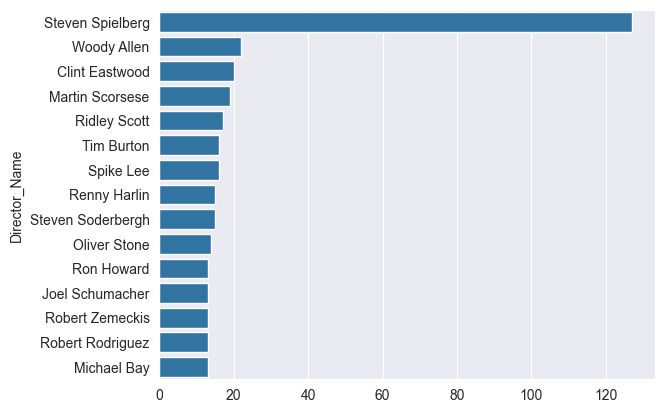

In [331]:
directors = movies_data["Director_Name"].value_counts().head(15)

sns.barplot(y=directors.index, x=directors.values)

Больше всего фильмов снял Стивен Спилберг.

In [332]:
movies_data["color"].value_counts()

color
Color               4725
 Black and White     205
Name: count, dtype: int64

### Кодирование категориальных признаков

Закодируем жанры фильмов.

In [333]:
binarizer = sk.MultiLabelBinarizer()

genres_list = movies_data["genres"].str.split("|")

genres_encoded = binarizer.fit_transform(genres_list)
genres_encoded_df = pd.DataFrame(genres_encoded, index=movies_data.index, columns=binarizer.classes_)

movies_data = pd.concat([movies_data, genres_encoded_df], axis=1)
movies_data.drop(["genres"], axis=1, inplace=True)

movies_data

,color,Director_Name,num_Critic_for_reviews,duration,director_Facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,actor_1_name,...,Mystery,News,Reality-TV,Romance,Sci-Fi,Short,Sport,Thriller,War,Western
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,CCH Pounder,...,0,0,0,0,1,0,0,0,0,0
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Johnny Depp,...,0,0,0,0,0,0,0,0,0,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Christoph Waltz,...,0,0,0,0,0,0,0,1,0,0
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Tom Hardy,...,0,0,0,0,0,0,0,1,0,0
4,Color,Doug Walker,110.0,103.0,131.0,372.0,Rob Walker,131.0,25529689.0,Doug Walker,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4969,Color,Scott Smith,1.0,87.0,2.0,318.0,Daphne Zuniga,637.0,25529689.0,Eric Mabius,...,0,0,0,0,0,0,0,0,0,0
4970,Color,Steven Spielberg,43.0,43.0,49.0,319.0,Valorie Curry,841.0,25529689.0,Natalie Zea,...,1,0,0,0,0,0,0,1,0,0
4971,Color,Benjamin Roberds,13.0,76.0,0.0,0.0,Maxwell Moody,0.0,25529689.0,Eva Boehnke,...,0,0,0,0,0,0,0,1,0,0
4972,Color,Daniel Hsia,14.0,100.0,0.0,489.0,Daniel Henney,946.0,10443.0,Alan Ruck,...,0,0,0,1,0,0,0,0,0,0


In [334]:
categorial_encoded_df = (pd.get_dummies(movies_data[["content_rating", "language", "country"]])).astype(int)

movies_data = pd.concat([movies_data, categorial_encoded_df], axis=1)
movies_data.drop(["content_rating", "language", "country"], axis=1, inplace=True)

movies_data

,color,Director_Name,num_Critic_for_reviews,duration,director_Facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,actor_1_name,...,country_Spain,country_Sweden,country_Switzerland,country_Taiwan,country_Thailand,country_Turkey,country_UK,country_USA,country_United Arab Emirates,country_West Germany
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,CCH Pounder,...,0,0,0,0,0,0,0,1,0,0
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Johnny Depp,...,0,0,0,0,0,0,0,1,0,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Christoph Waltz,...,0,0,0,0,0,0,1,0,0,0
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Tom Hardy,...,0,0,0,0,0,0,0,1,0,0
4,Color,Doug Walker,110.0,103.0,131.0,372.0,Rob Walker,131.0,25529689.0,Doug Walker,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4969,Color,Scott Smith,1.0,87.0,2.0,318.0,Daphne Zuniga,637.0,25529689.0,Eric Mabius,...,0,0,0,0,0,0,0,0,0,0
4970,Color,Steven Spielberg,43.0,43.0,49.0,319.0,Valorie Curry,841.0,25529689.0,Natalie Zea,...,0,0,0,0,0,0,0,1,0,0
4971,Color,Benjamin Roberds,13.0,76.0,0.0,0.0,Maxwell Moody,0.0,25529689.0,Eva Boehnke,...,0,0,0,0,0,0,0,1,0,0
4972,Color,Daniel Hsia,14.0,100.0,0.0,489.0,Daniel Henney,946.0,10443.0,Alan Ruck,...,0,0,0,0,0,0,0,1,0,0


In [335]:
ordinal_encoder = sk.OrdinalEncoder()
names_columns=["Director_Name",
        "actor_2_name",
        "actor_1_name",
        "actor_3_name"]
movies_data[names_columns] = ordinal_encoder.fit_transform(movies_data[names_columns])
movies_data

,color,Director_Name,num_Critic_for_reviews,duration,director_Facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,actor_1_name,...,country_Spain,country_Sweden,country_Switzerland,country_Taiwan,country_Thailand,country_Turkey,country_UK,country_USA,country_United Arab Emirates,country_West Germany
0,Color,913.0,723.0,178.0,0.0,855.0,1391.0,1000.0,760505847.0,260.0,...,0,0,0,0,0,0,0,1,0,0
1,Color,786.0,302.0,169.0,563.0,1000.0,2193.0,40000.0,309404152.0,964.0,...,0,0,0,0,0,0,0,1,0,0
2,Color,1998.0,602.0,148.0,0.0,161.0,2461.0,11000.0,200074175.0,343.0,...,0,0,0,0,0,0,1,0,0,0
3,Color,370.0,813.0,164.0,22000.0,23000.0,527.0,27000.0,448130642.0,1935.0,...,0,0,0,0,0,0,0,1,0,0
4,Color,595.0,110.0,103.0,131.0,372.0,2406.0,131.0,25529689.0,516.0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4969,Color,2024.0,1.0,87.0,2.0,318.0,666.0,637.0,25529689.0,587.0,...,0,0,0,0,0,0,0,0,0,0
4970,Color,2132.0,43.0,43.0,49.0,319.0,2867.0,841.0,25529689.0,1423.0,...,0,0,0,0,0,0,0,1,0,0
4971,Color,185.0,13.0,76.0,0.0,0.0,1951.0,0.0,25529689.0,605.0,...,0,0,0,0,0,0,0,1,0,0
4972,Color,448.0,14.0,100.0,0.0,489.0,644.0,946.0,10443.0,30.0,...,0,0,0,0,0,0,0,1,0,0


In [336]:
movies_data["color"] = movies_data["color"].map({"Color": 1, "Black and White": 0})
movies_data

,color,Director_Name,num_Critic_for_reviews,duration,director_Facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,actor_1_name,...,country_Spain,country_Sweden,country_Switzerland,country_Taiwan,country_Thailand,country_Turkey,country_UK,country_USA,country_United Arab Emirates,country_West Germany
0,1.0,913.0,723.0,178.0,0.0,855.0,1391.0,1000.0,760505847.0,260.0,...,0,0,0,0,0,0,0,1,0,0
1,1.0,786.0,302.0,169.0,563.0,1000.0,2193.0,40000.0,309404152.0,964.0,...,0,0,0,0,0,0,0,1,0,0
2,1.0,1998.0,602.0,148.0,0.0,161.0,2461.0,11000.0,200074175.0,343.0,...,0,0,0,0,0,0,1,0,0,0
3,1.0,370.0,813.0,164.0,22000.0,23000.0,527.0,27000.0,448130642.0,1935.0,...,0,0,0,0,0,0,0,1,0,0
4,1.0,595.0,110.0,103.0,131.0,372.0,2406.0,131.0,25529689.0,516.0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4969,1.0,2024.0,1.0,87.0,2.0,318.0,666.0,637.0,25529689.0,587.0,...,0,0,0,0,0,0,0,0,0,0
4970,1.0,2132.0,43.0,43.0,49.0,319.0,2867.0,841.0,25529689.0,1423.0,...,0,0,0,0,0,0,0,1,0,0
4971,1.0,185.0,13.0,76.0,0.0,0.0,1951.0,0.0,25529689.0,605.0,...,0,0,0,0,0,0,0,1,0,0
4972,1.0,448.0,14.0,100.0,0.0,489.0,644.0,946.0,10443.0,30.0,...,0,0,0,0,0,0,0,1,0,0


### Стандартизация и масштабирование

Так как числовые данные имеют высокий размах, перед масштабированием применим логарифмирование.

In [340]:
columns_for_edit = numeric_columns.drop(["aspect_ratio", "title_year"])
log_data = movies_data.copy()

for column in columns_for_edit:
    log_data[column] = np.log(log_data[column] + 1)
log_data

,color,Director_Name,num_Critic_for_reviews,duration,director_Facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,actor_1_name,...,country_Spain,country_Sweden,country_Switzerland,country_Taiwan,country_Thailand,country_Turkey,country_UK,country_USA,country_United Arab Emirates,country_West Germany
0,1.0,913.0,6.584791,5.187386,0.000000,6.752270,1391.0,6.908755,20.449494,260.0,...,0,0,0,0,0,0,0,1,0,0
1,1.0,786.0,5.713733,5.135798,6.335054,6.908755,2193.0,10.596660,19.550159,964.0,...,0,0,0,0,0,0,0,1,0,0
2,1.0,1998.0,6.401917,5.003946,0.000000,5.087596,2461.0,9.305741,19.114199,343.0,...,0,0,0,0,0,0,1,0,0,0
3,1.0,370.0,6.701960,5.105945,9.998843,10.043293,527.0,10.203629,19.920595,1935.0,...,0,0,0,0,0,0,0,1,0,0
4,1.0,595.0,4.709530,4.644391,4.882802,5.921578,2406.0,4.882802,17.055353,516.0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4969,1.0,2024.0,0.693147,4.477337,1.098612,5.765191,666.0,6.458338,17.055353,587.0,...,0,0,0,0,0,0,0,0,0,0
4970,1.0,2132.0,3.784190,3.784190,3.912023,5.768321,2867.0,6.735780,17.055353,1423.0,...,0,0,0,0,0,0,0,1,0,0
4971,1.0,185.0,2.639057,4.343805,0.000000,0.000000,1951.0,0.000000,17.055353,605.0,...,0,0,0,0,0,0,0,1,0,0
4972,1.0,448.0,2.708050,4.615121,0.000000,6.194405,644.0,6.853299,9.253783,30.0,...,0,0,0,0,0,0,0,1,0,0


array([[<Axes: title={'center': 'num_Critic_for_reviews'}>,
        <Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'director_Facebook_likes'}>,
        <Axes: title={'center': 'actor_3_facebook_likes'}>],
       [<Axes: title={'center': 'actor_1_facebook_likes'}>,
        <Axes: title={'center': 'gross'}>,
        <Axes: title={'center': 'num_voted_users'}>,
        <Axes: title={'center': 'cast_total_facebook_likes'}>],
       [<Axes: title={'center': 'facenumber_in_poster'}>,
        <Axes: title={'center': 'num_user_for_reviews'}>,
        <Axes: title={'center': 'budget'}>,
        <Axes: title={'center': 'actor_2_facebook_likes'}>],
       [<Axes: title={'center': 'imdb_score'}>,
        <Axes: title={'center': 'movie_facebook_likes'}>, <Axes: >,
        <Axes: >]], dtype=object)

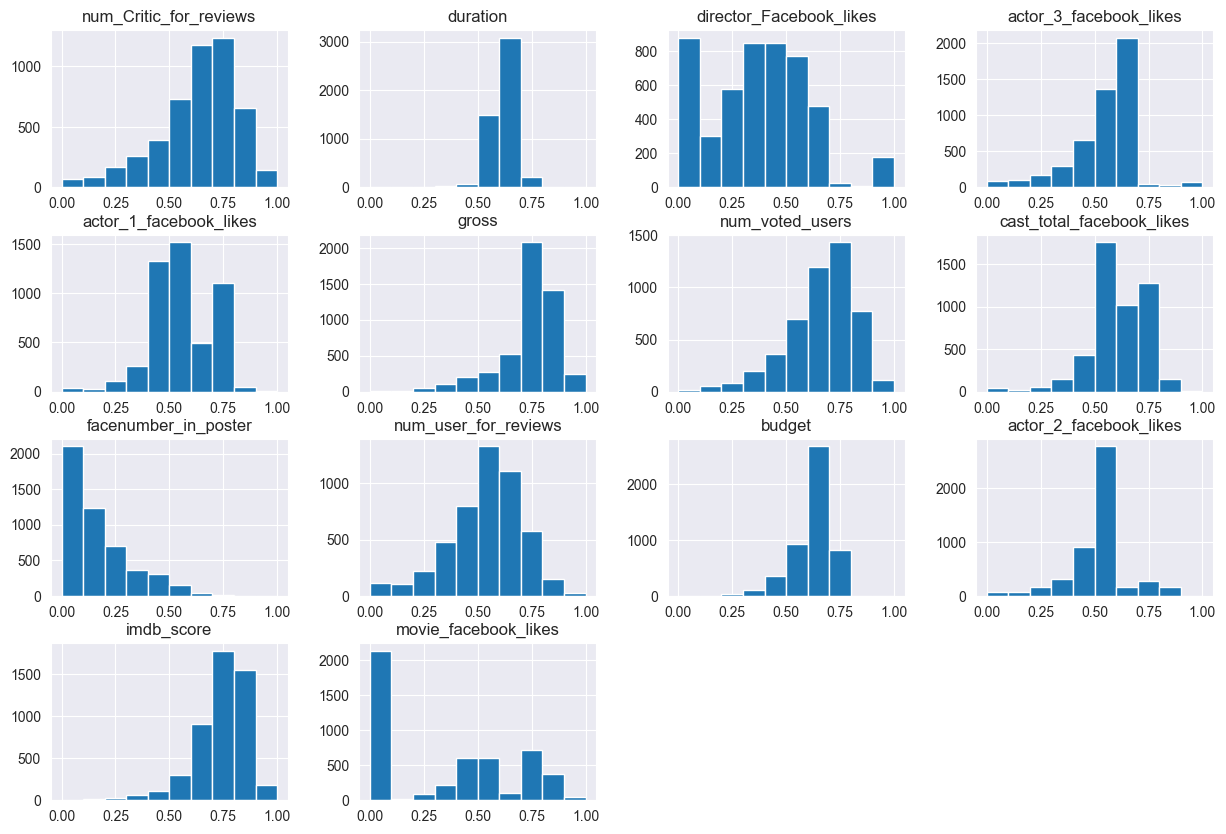

In [341]:
copy_data = log_data.copy()


min_max_scaler = sk.MinMaxScaler()
std_scaler = sk.StandardScaler()

scaling_values = min_max_scaler.fit_transform(copy_data[columns_for_edit])
std_values = std_scaler.fit_transform(scaling_values)

scaling_movies_data = pd.DataFrame(scaling_values, columns=columns_for_edit)


scaling_movies_data.hist(figsize=(15, 10))

### Итог

В датасете есть как особо популярные фильмы с большими кассовыми сборами, так и фильмы, провалившиеся в прокате.

Наиболее успешными фильмами в коммерческом смысле являются картины с низким возрастным рейтингом, предназначенные для широкой аудитории.

Практически все фильмы из датасета были произведены в США.

Популярность и коммерческий успех фильма также зависит от степени известности режиссера и актерского состава - чем они известнее, тем фильм популярнее.

Наиболее высоко оцененные фильмы имеют большое число оценок от зрителей - это говорит о том, что качественные фильмы привлекают большую аудиторию.

